# Ambyint Data Scientist Assessment: Industrial System Analysis

### **Name:** Vashisht Marhwal
### **Date:** May 29, 2025

### Introduction
- The notebook focuses on analyzing time-series data from a simulated industrial well to understand its operational patterns and predict potential alert conditions. It demonstrates an end-to-end data science workflow, from initial data exploration and preprocessing to feature engineering, model development, and evaluation for an monitoring_alert prediction task.

### Setup and Packages

In [1]:
# Install requirements if missing
!pip install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import joblib
import os
import warnings

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV



In [3]:
from utils.data_utils import (clean_and_convert_types, missing_values_analysis, drop_columns,
                                   handle_missing_values, create_time_features, one_hot_encode_categorical,
                                   scale_features_robust, create_lagged_features)

from utils.model_utils import (evaluate_model, run_feature_importance_analysis, perform_cross_validation)

warnings.filterwarnings('ignore')


## Part 1: Monitoring Alert Prediction

## Objective
- Exploring and understanding the provided data, identifying its characteristics, complexities, and potential data quality issues.
- Implementing appropriate data preprocessing and cleaning techniques to prepare the data for modeling.
- Engineering relevant features from the raw data, such as time-based attributes or feature lags, to improve the predictive power of the chosen model.
- Addressing potential class imbalance if any.
- Training, evaluating a robust classification model.
- Interpreting model results to derive insights into factors leading to alert conditions.


### 1.1. Data Loading and Initial Exploration (EDA)

In [4]:
try:
    train_df = pl.read_csv("dataset/train.csv")
    test_df = pl.read_csv("dataset/test.csv")
    print("Data Loaded Successfully")
except FileNotFoundError:
    print("CSV files not found. Please ensure 'train.csv' and 'test.csv' are in the correct directory.")

Data Loaded Successfully


#### - Training Data Description and Schema

In [5]:
print("Train DataFrame:")
print(train_df.head())

Train DataFrame:
shape: (5, 22)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ Well_ID ┆ Timestamp  ┆ Well_Oper ┆ Operation ┆ … ┆ Surface_T ┆ Tubing_Pr ┆ VFD_Speed ┆ Monitorin │
│ ---     ┆ ---        ┆ ating_Sta ┆ al_Notes  ┆   ┆ emperatur ┆ essure_ps ┆ _pct      ┆ g_Alert   │
│ i64     ┆ str        ┆ tus       ┆ ---       ┆   ┆ e_C       ┆ i         ┆ ---       ┆ ---       │
│         ┆            ┆ ---       ┆ str       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ i64       │
│         ┆            ┆ str       ┆           ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 101     ┆ 2023-01-01 ┆ Operating ┆ null      ┆ … ┆ 64.128805 ┆ 197.27372 ┆ 67.414439 ┆ 0         │
│         ┆ 00:00:00   ┆           ┆           ┆   ┆           ┆ 1         ┆           ┆           │
│ 101     ┆ 2023-01-01 ┆ Operating ┆ null      ┆ … ┆ 64.625

In [6]:
print(train_df.describe())

shape: (9, 23)
┌────────────┬─────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ Well_ID ┆ Timestamp ┆ Well_Oper ┆ … ┆ Surface_T ┆ Tubing_Pr ┆ VFD_Speed ┆ Monitorin │
│ ---        ┆ ---     ┆ ---       ┆ ating_Sta ┆   ┆ emperatur ┆ essure_ps ┆ _pct      ┆ g_Alert   │
│ str        ┆ f64     ┆ str       ┆ tus       ┆   ┆ e_C       ┆ i         ┆ ---       ┆ ---       │
│            ┆         ┆           ┆ ---       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆         ┆           ┆ str       ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 40787.0 ┆ 40787     ┆ 40787     ┆ … ┆ 40192.0   ┆ 39794.0   ┆ 39970.0   ┆ 40787.0   │
│ null_count ┆ 0.0     ┆ 0         ┆ 0         ┆ … ┆ 595.0     ┆ 993.0     ┆ 817.0     ┆ 0.0       │
│ mean       ┆ 101.0   ┆ null      ┆ null      ┆ … ┆ 60.740131 ┆ 187.60566 ┆

In [7]:
train_df.schema

Schema([('Well_ID', Int64),
        ('Timestamp', String),
        ('Well_Operating_Status', String),
        ('Operational_Notes', String),
        ('Acoustic_Sensor_Env_dB', Float64),
        ('Ambient_Temperature_C', Float64),
        ('Casing_Pressure_SensorB_psi', Float64),
        ('Casing_Pressure_psi', Float64),
        ('Gearbox_Temperature_C', Float64),
        ('Gearbox_Vibration_mm_s', Float64),
        ('Hydraulic_Pressure_psi', Float64),
        ('Liquid_Flow_Rate_m3d', Float64),
        ('Lubrication_Status', String),
        ('Maintenance_Code', Int64),
        ('Motor_Power_kW', Float64),
        ('Polished_Rod_Vibration_mm_s', Float64),
        ('Seismic_Activity_Index', Float64),
        ('Stroke_Count_Today', Int64),
        ('Surface_Temperature_C', Float64),
        ('Tubing_Pressure_psi', Float64),
        ('VFD_Speed_pct', Float64),
        ('Monitoring_Alert', Int64)])

#### - Testing Data Description and Schema

In [8]:
print("\nTest DataFrame:")
print(test_df.head())


Test DataFrame:
shape: (5, 21)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ Well_ID ┆ Timestamp  ┆ Well_Oper ┆ Operation ┆ … ┆ Stroke_Co ┆ Surface_T ┆ Tubing_Pr ┆ VFD_Speed │
│ ---     ┆ ---        ┆ ating_Sta ┆ al_Notes  ┆   ┆ unt_Today ┆ emperatur ┆ essure_ps ┆ _pct      │
│ i64     ┆ str        ┆ tus       ┆ ---       ┆   ┆ ---       ┆ e_C       ┆ i         ┆ ---       │
│         ┆            ┆ ---       ┆ str       ┆   ┆ i64       ┆ ---       ┆ ---       ┆ f64       │
│         ┆            ┆ str       ┆           ┆   ┆           ┆ f64       ┆ f64       ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 101     ┆ 2023-10-19 ┆ Operating ┆ null      ┆ … ┆ 552       ┆ 63.167678 ┆ 177.64208 ┆ 72.621777 │
│         ┆ 23:00:00   ┆           ┆           ┆   ┆           ┆           ┆ 1         ┆           │
│ 101     ┆ 2023-10-19 ┆ Operating ┆ null      ┆ … ┆ 556   

In [9]:
print(test_df.describe())

shape: (9, 22)
┌────────────┬─────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ Well_ID ┆ Timestamp ┆ Well_Oper ┆ … ┆ Stroke_Co ┆ Surface_T ┆ Tubing_Pr ┆ VFD_Speed │
│ ---        ┆ ---     ┆ ---       ┆ ating_Sta ┆   ┆ unt_Today ┆ emperatur ┆ essure_ps ┆ _pct      │
│ str        ┆ f64     ┆ str       ┆ tus       ┆   ┆ ---       ┆ e_C       ┆ i         ┆ ---       │
│            ┆         ┆           ┆ ---       ┆   ┆ f64       ┆ ---       ┆ ---       ┆ f64       │
│            ┆         ┆           ┆ str       ┆   ┆           ┆ f64       ┆ f64       ┆           │
╞════════════╪═════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 10197.0 ┆ 10197     ┆ 10197     ┆ … ┆ 10197.0   ┆ 10039.0   ┆ 9934.0    ┆ 10009.0   │
│ null_count ┆ 0.0     ┆ 0         ┆ 0         ┆ … ┆ 0.0       ┆ 158.0     ┆ 263.0     ┆ 188.0     │
│ mean       ┆ 101.0   ┆ null      ┆ null      ┆ … ┆ 286.26498 ┆ 65.050646 ┆

In [10]:
test_df.schema

Schema([('Well_ID', Int64),
        ('Timestamp', String),
        ('Well_Operating_Status', String),
        ('Operational_Notes', String),
        ('Acoustic_Sensor_Env_dB', Float64),
        ('Ambient_Temperature_C', Float64),
        ('Casing_Pressure_SensorB_psi', Float64),
        ('Casing_Pressure_psi', Float64),
        ('Gearbox_Temperature_C', Float64),
        ('Gearbox_Vibration_mm_s', Float64),
        ('Hydraulic_Pressure_psi', Float64),
        ('Liquid_Flow_Rate_m3d', Float64),
        ('Lubrication_Status', String),
        ('Maintenance_Code', Int64),
        ('Motor_Power_kW', Float64),
        ('Polished_Rod_Vibration_mm_s', Float64),
        ('Seismic_Activity_Index', Float64),
        ('Stroke_Count_Today', Int64),
        ('Surface_Temperature_C', Float64),
        ('Tubing_Pressure_psi', Float64),
        ('VFD_Speed_pct', Float64)])

#### Feature Description

- `Well_ID`: Unique identifier for the specific well.
- `Timestamp`: Date and time of the data recording (provided as a string).
- `Well_Operating_Status`: Status describing the operational state of the well.
- `Operational_Notes`: Notes related to well operations.
- `Acoustic_Sensor_Env_dB`: Noise level in decibels (dB) recorded by an acoustic sensor.
- `Ambient_Temperature_C`: Surrounding air temperature in degrees Celsius (°C).
- `Casing_Pressure_SensorB_psi`: Pressure measured by a sensor B on the well casing, in psi.
- `Casing_Pressure_psi`: Pressure reading from the well casing, in psi.
- `Gearbox_Temperature_C`: Temperature of the pump's gearbox in degrees Celsius (°C).
- `Gearbox_Vibration_mm_s`: Vibration level of the gearbox, measured in mm/s.
- `Hydraulic_Pressure_psi`: Pressure within the hydraulic system of the equipment, in psi.
- `Liquid_Flow_Rate_m3d`: Rate of liquid production from the well, in m³/d.
- `Lubrication_Status`: Status indicating the state of the equipment's lubrication system.
- `Maintenance_Code`: Integer code representing a type of maintenance activity or status.
- `Motor_Power_kW`: Electrical power consumption of the pump motor, in kilowatts (kW).
- `Polished_Rod_Vibration_mm_s`: Vibration level measured at the polished rod of a pumping unit, in mm/s.
- `Seismic_Activity_Index`: A numerical index representing the level of local seismic activity.
- `Stroke_Count_Today`: Cumulative number of pump strokes recorded for the current day.
- `Surface_Temperature_C`: Temperature measured at the surface near the well equipment, in °C.
- `Tubing_Pressure_psi`: Pressure inside the production tubing of the well, in psi.
- `VFD_Speed_pct`: Operating speed of the Variable Frequency Drive (VFD) as a percentage (%) of its maximum speed.
- `Monitoring_Alert`: Integer code indicating a specific monitoring alert status (e.g., 0 for normal, 1 for an alert).

Before further understanding the data, we will do some type conversion

##### 1.1.1. Data Cleaning and Type Conversion

In [11]:
try:
    train_df = clean_and_convert_types(train_df)
    test_df = clean_and_convert_types(test_df)

    print("Train DataFrame after schema-aware renaming and type conversion:")
    print(train_df.head(3))
    print(train_df.schema)

    print("\nTest DataFrame after schema-aware renaming and type conversion:")
    print(train_df.head(3))
    print(train_df.schema)

except NameError:
    print("Error: train_df_pl or test_df_pl not defined. Please load your data first.")
except Exception as e:
    print(f"An error occurred during cleaning and type conversion: {e}")

Train DataFrame after schema-aware renaming and type conversion:
shape: (3, 22)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ well_id ┆ timestamp  ┆ well_oper ┆ operation ┆ … ┆ surface_t ┆ tubing_pr ┆ vfd_speed ┆ monitorin │
│ ---     ┆ ---        ┆ ating_sta ┆ al_notes  ┆   ┆ emperatur ┆ essure_ps ┆ _pct      ┆ g_alert   │
│ i64     ┆ datetime[μ ┆ tus       ┆ ---       ┆   ┆ e_c       ┆ i         ┆ ---       ┆ ---       │
│         ┆ s]         ┆ ---       ┆ str       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ i64       │
│         ┆            ┆ str       ┆           ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 101     ┆ 2023-01-01 ┆ Operating ┆ null      ┆ … ┆ 64.128805 ┆ 197.27372 ┆ 67.414439 ┆ 0         │
│         ┆ 00:00:00   ┆           ┆           ┆   ┆           ┆ 1         ┆           ┆           │
│ 101     ┆

##### 1.1.2. Understanding Basic Data

In [12]:
# Unique Well IDs
unique_well_ids = train_df.get_column("well_id").unique().sort().to_list()
print(f"Unique Well IDs: {unique_well_ids}")

Unique Well IDs: [101]


#### **This entire dataset corresponds to one unique well with ID = 101**

In [13]:
# Time Range of the data
min_timestamp = train_df.get_column("timestamp").min()
max_timestamp = train_df.get_column("timestamp").max()

print(f"\nEarliest Timestamp: {min_timestamp}")
print(f"Latest Timestamp:   {max_timestamp}")


Earliest Timestamp: 2023-01-01 00:00:00
Latest Timestamp:   2023-10-19 22:50:00


#### **This entire training in between the time range of January 1st, 2023 to October 19th, 2023**

In [14]:
# Shape of Data before pre-processing
train_df.shape

(40787, 22)

#### **- There are a total of 40,787 records in the training data**
#### **- There are a total of 21 features in the dataset and 1 target label (monitoring_alert)**

##### Unique Categorical Variable

In [15]:
# Unique Operating Status of the Well\
train_df.get_column("well_operating_status").unique().sort().to_list()

['Maintenance', 'Operating', 'Standby', 'Startup']

#### **- The well can be in following Operating stages: ['Maintenance', 'Operating', 'Standby', 'Startup']**


##### 1.1.3. Missing Value Analysis

Before proceeding with our statistical analysis, it's important to assess the extent of missing data to ensure data quality and inform appropriate handling strategies.

In [16]:
missing_values_analysis(train_df)

column,dtype,missing_count,missing_pct
str,str,i64,f64
"""operational_notes""","""String""",38946,95.486307
"""lubrication_status""","""String""",36778,90.170888
"""maintenance_code""","""Int64""",34592,84.811337
"""liquid_flow_rate_m3d""","""Float64""",1227,3.008311
"""tubing_pressure_psi""","""Float64""",993,2.434599
"""vfd_speed_pct""","""Float64""",817,2.003089
"""gearbox_temperature_c""","""Float64""",806,1.97612
"""surface_temperature_c""","""Float64""",595,1.458798
"""acoustic_sensor_env_db""","""Float64""",410,1.005222


In [17]:
missing_values_analysis(test_df)

column,dtype,missing_count,missing_pct
str,str,i64,f64
"""operational_notes""","""String""",9746,95.577131
"""lubrication_status""","""String""",9158,89.810729
"""maintenance_code""","""Int64""",8745,85.760518
"""liquid_flow_rate_m3d""","""Float64""",280,2.745906
"""tubing_pressure_psi""","""Float64""",263,2.57919
"""gearbox_temperature_c""","""Float64""",199,1.951554
"""vfd_speed_pct""","""Float64""",188,1.84368
"""surface_temperature_c""","""Float64""",158,1.549475
"""acoustic_sensor_env_db""","""Float64""",92,0.902226


#### Strategy to handle missing data will be discussed after further analysis on these features. 

##### 1.1.4. Target Variable Distribution

In [18]:
target_col = 'monitoring_alert'

alert_counts = train_df[target_col].value_counts().sort(target_col)
print("\nMonitoring Alert Distribution:")
print(alert_counts)


Monitoring Alert Distribution:
shape: (2, 2)
┌──────────────────┬───────┐
│ monitoring_alert ┆ count │
│ ---              ┆ ---   │
│ i64              ┆ u32   │
╞══════════════════╪═══════╡
│ 0                ┆ 36912 │
│ 1                ┆ 3875  │
└──────────────────┴───────┘


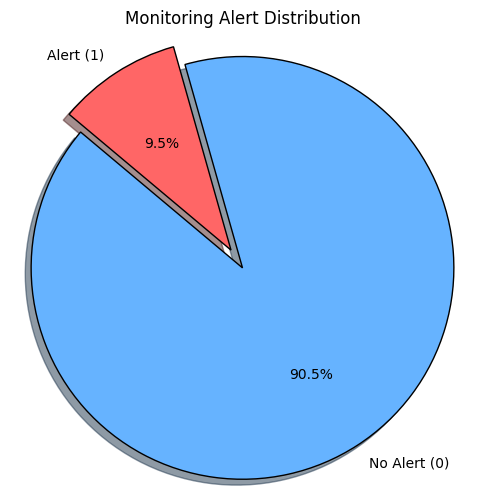

In [19]:
# CONVERTING TO PANDAS FOR VISUALIZATION
alert_counts_pd = alert_counts.to_pandas()

labels = ['No Alert (0)', 'Alert (1)']
sizes = alert_counts_pd['count']
colors = ['#66b3ff', '#ff6666']
explode = (0, 0.1)

plt.figure(figsize=(6, 6))
plt.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    startangle=140, colors=colors, explode=explode,
    shadow=True, wedgeprops={'edgecolor': 'black'}
)
plt.title('Monitoring Alert Distribution')
plt.axis('equal')
plt.show()

### **Interpretation of Target Variable:**
##### **Imbalance:** The dataset is imbalanced (alerts are rare). This is important for model selection, evaluation metrics and potentially resampling techniques or using class weights.

#### 1.1.5. Time Series Exploration

##### 1.1.5.1. Time Series - Alert Trend

In [20]:
# Extract just the date
train_df_temp = train_df.with_columns([
    pl.col("timestamp").dt.date().alias("date")
])

# Group by date, totaling the number of alerts per day
daily_alerts = (
    train_df_temp.group_by("date")
    .agg(pl.col("monitoring_alert").sum().alias("daily_alert_count"))
    .sort("date")
)

alert_trend_df = daily_alerts.to_pandas()

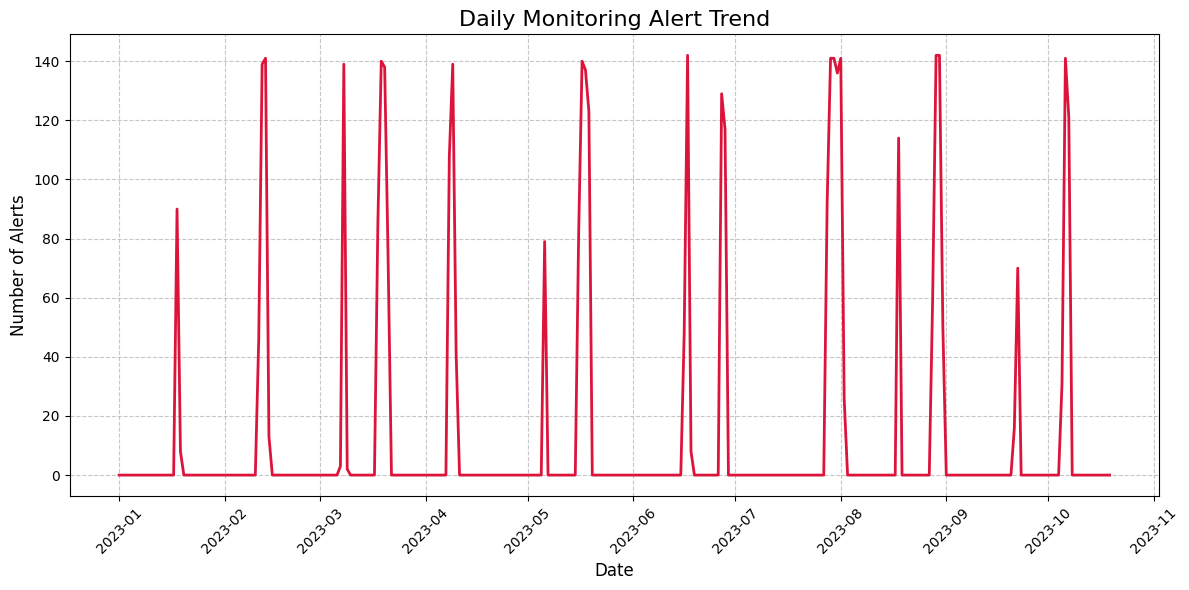

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(alert_trend_df["date"], alert_trend_df["daily_alert_count"], color='crimson', linewidth=2)
plt.title("Daily Monitoring Alert Trend", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Alerts", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation:
1. `Periodic Alerts` - Alerts are not randomly distributed. They occur in distinct, high-intensity bursts lasting 2–4 days. These periods show sharp spikes, followed by stable intervals with near-zero alerts.

2. `Cyclical Patterns` Across Months - Alerts appear to repeat roughly monthly between selected time-period 

3. `System Stability Between Events` - Between alert periods, the system remains quiet with minimal or no alerts, indicating stable operations.

##### 1.1.5.2. Sensor Trend Plots over Time

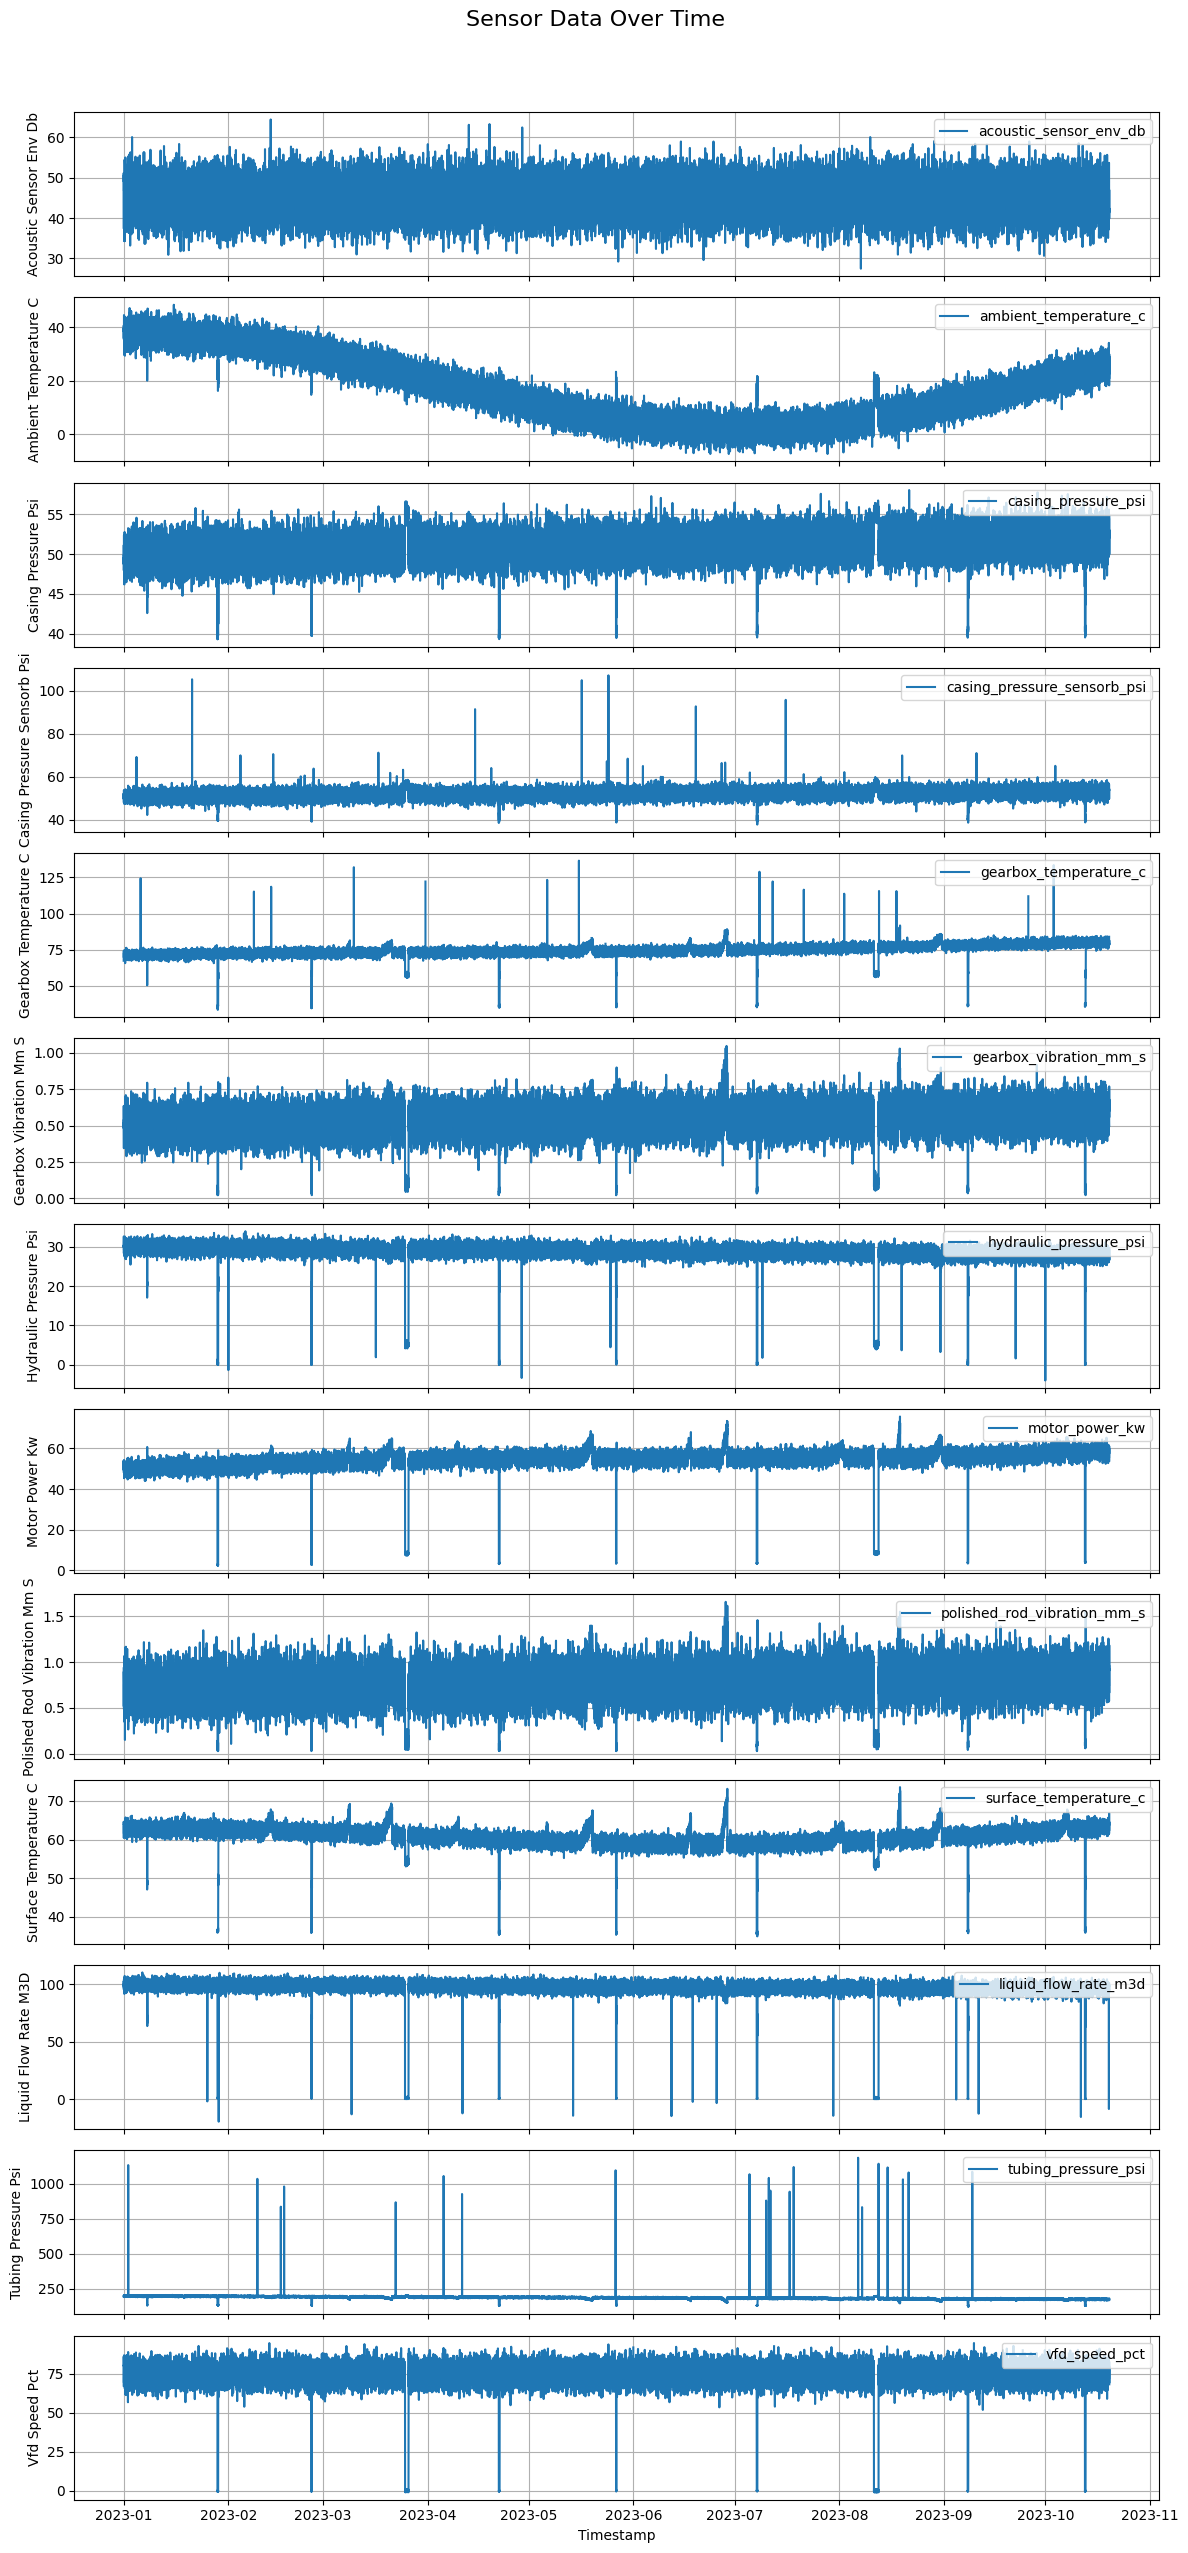

In [22]:
sensors_to_plot = [
    'acoustic_sensor_env_db',
    'ambient_temperature_c',
    'casing_pressure_psi',
    'casing_pressure_sensorb_psi',
    'gearbox_temperature_c',
    'gearbox_vibration_mm_s',
    'hydraulic_pressure_psi',
    'motor_power_kw',
    'polished_rod_vibration_mm_s',
    'surface_temperature_c',
    'liquid_flow_rate_m3d',
    'tubing_pressure_psi',
    'vfd_speed_pct',
]

fig, axes = plt.subplots(nrows=len(sensors_to_plot), ncols=1, figsize=(12, 2 * len(sensors_to_plot)), sharex=True)

# Plot each selected sensor
for i, sensor_col in enumerate(sensors_to_plot):
    if sensor_col in train_df.columns:
        axes[i].plot(train_df['timestamp'], train_df[sensor_col], label=sensor_col)
        axes[i].set_ylabel(sensor_col.replace('_', ' ').title())
        axes[i].legend(loc='upper right')
        axes[i].grid(True)
    else:
        print(f"Warning: Column '{sensor_col}' not found in DataFrame.")

fig.suptitle('Sensor Data Over Time', fontsize=16)
axes[-1].set_xlabel('Timestamp') # Set x-axis label only on the last subplot

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make space for suptitle
plt.show()


- **Key Insights:**
    - A drop in Motor Power, potentially linked to an operational event, correlates with a decrease in readings from several other sensors, but notably, an increase in Tubing Pressure.
    - A decrease in Gearbox Temperature is associated with a drop in Gearbox Vibration, often indicates reduced operational intensity
    - A drop in Hydraulic Pressure correlates with a decrease in Liquid Flow Rate. A reduction in available hydraulic pressure directly decreases the system's capacity to move fluid, resulting in a lower liquid flow rate.

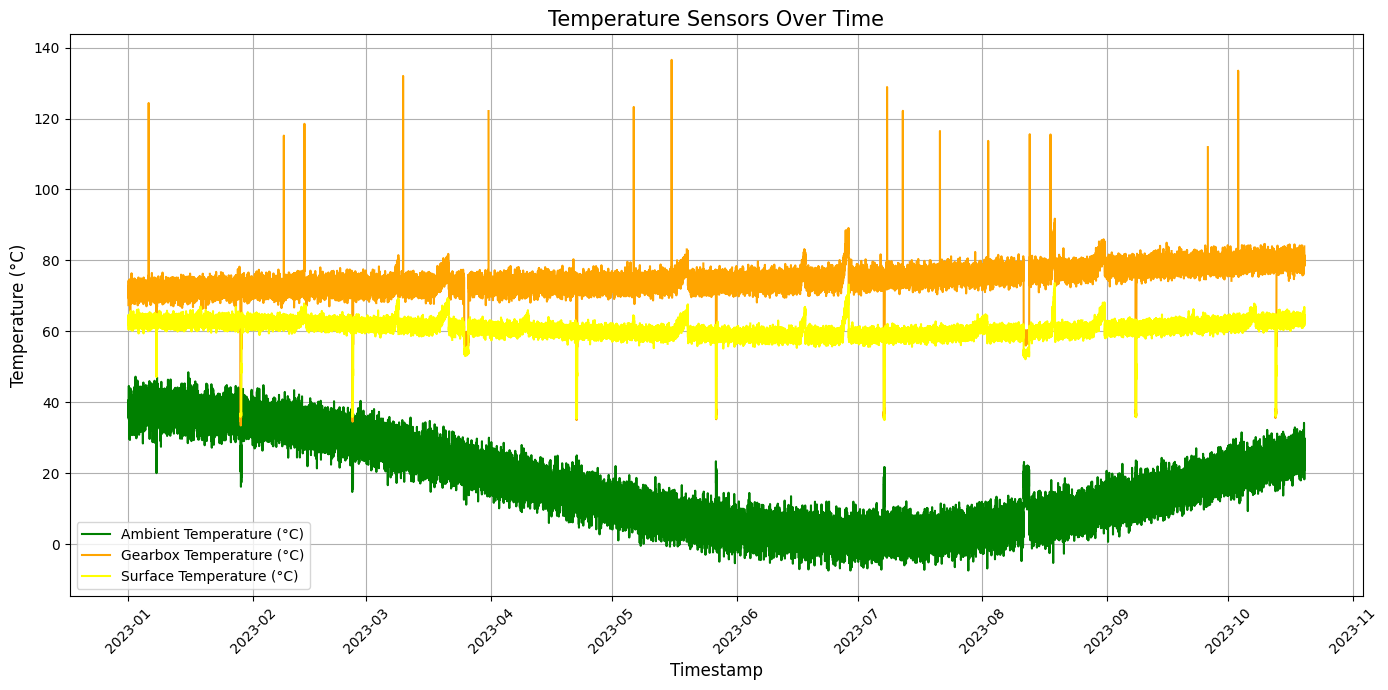

In [23]:
plt.figure(figsize=(14, 7))


plt.plot(train_df['timestamp'], train_df['ambient_temperature_c'], label='Ambient Temperature (°C)', color='green')
plt.plot(train_df['timestamp'], train_df['gearbox_temperature_c'], label='Gearbox Temperature (°C)', color='orange')
plt.plot(train_df['timestamp'], train_df['surface_temperature_c'], label='Surface Temperature (°C)', color='yellow')

plt.title('Temperature Sensors Over Time', fontsize=15)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- **Key Insights:**
    - Seasonal Influence: All temperatures follow seasonal ambient variations.
    - Gearbox Temperature Spikes: The Gearbox Temperature exhibits frequent, very sharp, short-duration spikes. Suggests intermittent high stress events.
    - Surface Temperature Dips: While generally stable and tracking above ambient conditions, the Surface Temperature displays several brief, and sharp downward dips. Might indicate short-lived events possibly related to equipment shutdowns

#### 1.1.5. Univariate Analysis - Histogram and Boxplots

In [24]:
# Selecting numerical features for following analysis
numerical_features = ['acoustic_sensor_env_db',
 'ambient_temperature_c',
 'casing_pressure_sensorb_psi',
 'casing_pressure_psi',
 'gearbox_temperature_c',
 'gearbox_vibration_mm_s',
 'hydraulic_pressure_psi',
 'liquid_flow_rate_m3d',
 'motor_power_kw',
 'polished_rod_vibration_mm_s',
 'seismic_activity_index',
 'stroke_count_today',
 'surface_temperature_c',
 'tubing_pressure_psi',
 'vfd_speed_pct'
 ]

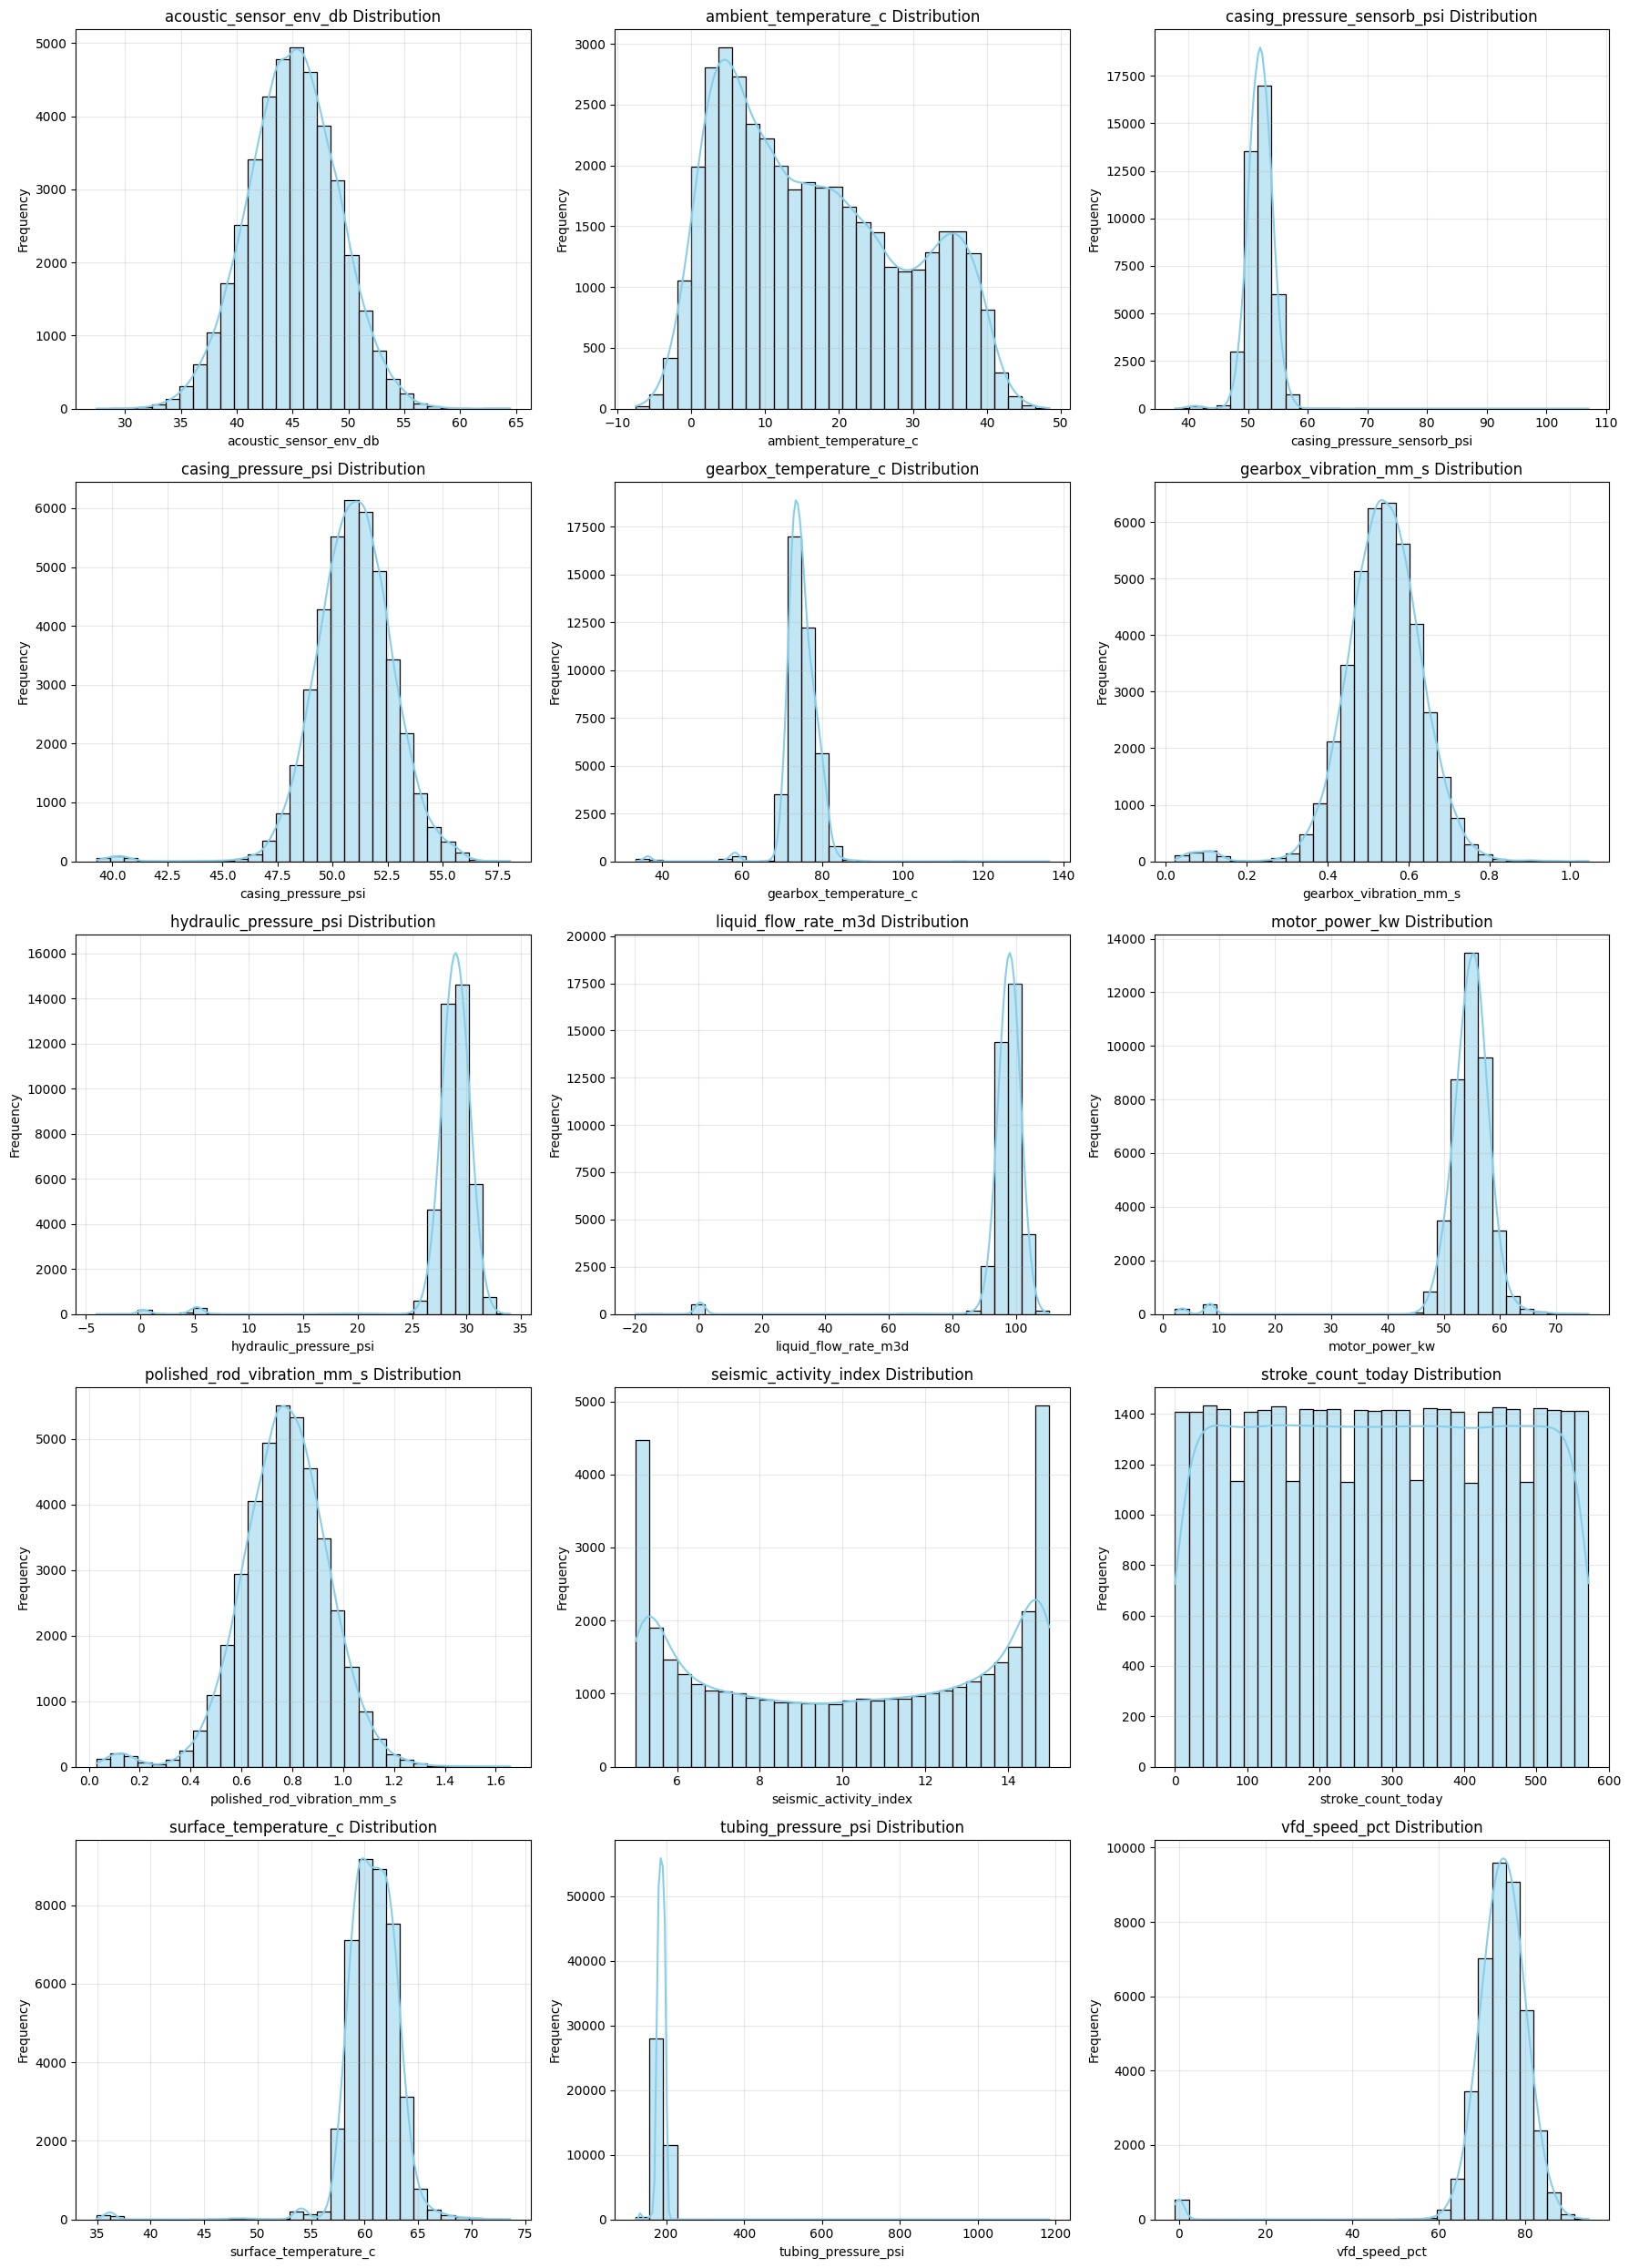

In [25]:
df_num = train_df.select(numerical_features).to_pandas()

num_cols = 3
num_rows = (len(numerical_features) + num_cols - 1) // num_cols
plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df_num[col], kde=True, bins=30, color="skyblue", edgecolor='black')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpertation:
1. `acoustic_sensor_env_db` Distribution: Appears roughly symmetrical and bell-shaped, resembling a normal distribution.
    
    This suggests that the acoustic environment noise levels are typically around a central value, with deviations becoming less frequent as they move further from this central point.

2. `ambient_temperature_c` Distribution: Distribution is multimodal, with at least two, possibly three, distinct peaks.
    
    The multiple peaks suggest that the ambient temperature experiences distinct common levels. This could be due to seasonal changes or day/night cycles

3. `casing_pressure_sensorb_psi` Distribution: Highly right-skewed with a very sharp peak at a low value and a long tail extending to higher pressures.
    
     This sensor usually reads a very low pressure. The higher pressure readings are much less frequent, possibly indicating specific events

4. `casing_pressure_psi` Distribution: Appears relatively symmetrical and bell-shaped
    
     This pressure sensor shows a fairly stable reading around a central value, with normal fluctuations.

5. `gearbox_temperature_c` Distribution: Extremely sharp peak around 70°C, with very little variation.
    
    The gearbox temperature is either very tightly controlled around a specific setpoint, or the sensor might be reporting a fixed value much of the time.

6. `gearbox_vibration_mm_s` Distribution: Right-skewed. A peak at lower vibration levels with a tail extending towards higher vibration levels.
    
     Gearbox vibration is typically low. Higher vibration readings are less common.

7. `hydraulic_pressure_psi` Distribution: Very sharp, tall peak at a specific value (around 23–25 psi), with slightly more spread than gearbox temperature.

    This suggests hydraulic pressure is tightly regulated at a common operating setpoint, with little deviation—indicating consistent system control during normal operation.

8. `liquid_flow_rate_m3d` Distribution: Distinct bimodal shape — one peak near 0 m³/d and another around 20–25 m³/d.

    The two modes imply "off" vs "active" operational states. Likely corresponds to pump cycles or binary flow states in well operation.

9. `motor_power_kw` Distribution: Right-skewed distribution with most values around 10–20 kW and a long tail up to ~70 kW.

    The motor generally runs at low power, but higher consumption periods exist—indicating operational variance based on task load or phases.

10. `polished_rod_vibration_mm_s` Distribution: Appears nearly symmetrical, centered around 0.4–0.6 mm/s.

    The vibration remains low and stable in normal conditions, with occasional higher values likely reflecting short-term mechanical stress.

11. `seismic_activity_index` Distribution: U-shaped distribution with higher frequencies at extremes (near 0 and 1), and fewer values in between.

    Suggests the system tends to either very low or very high seismic states—possibly a binary classification or monitoring threshold effect.

12. `stroke_count_today` Distribution: Appears uniformly distributed from ~0 to ~1000.

    No clear dominant count; stroke count fluctuates widely, possibly reflecting variable operational hours, workload, or reset cycles.

13. `surface_temperature_c` Distribution: Roughly symmetrical, centered around 30–35°C.

    Suggests stable and expected surface conditions with natural variability, likely influenced by ambient temperature or equipment exposure.

14. `tubing_pressure_psi` Distribution: Highly right-skewed with a sharp peak at low values (~100–200 psi) and a long tail up to 1200 psi.

    Most operations occur at low pressure, but the tail indicates rare high-pressure events that could be anomalies or intentional interventions.

15. `vfd_speed_pct` Distribution: Somewhat bimodal — primary peak around 80–90% and secondary peak near 0%, with a dip in the mid-range.

    Indicates VFD is often either fully active or near idle. This suggests a binary operating mode: "on at high speed" vs. "off/minimal."

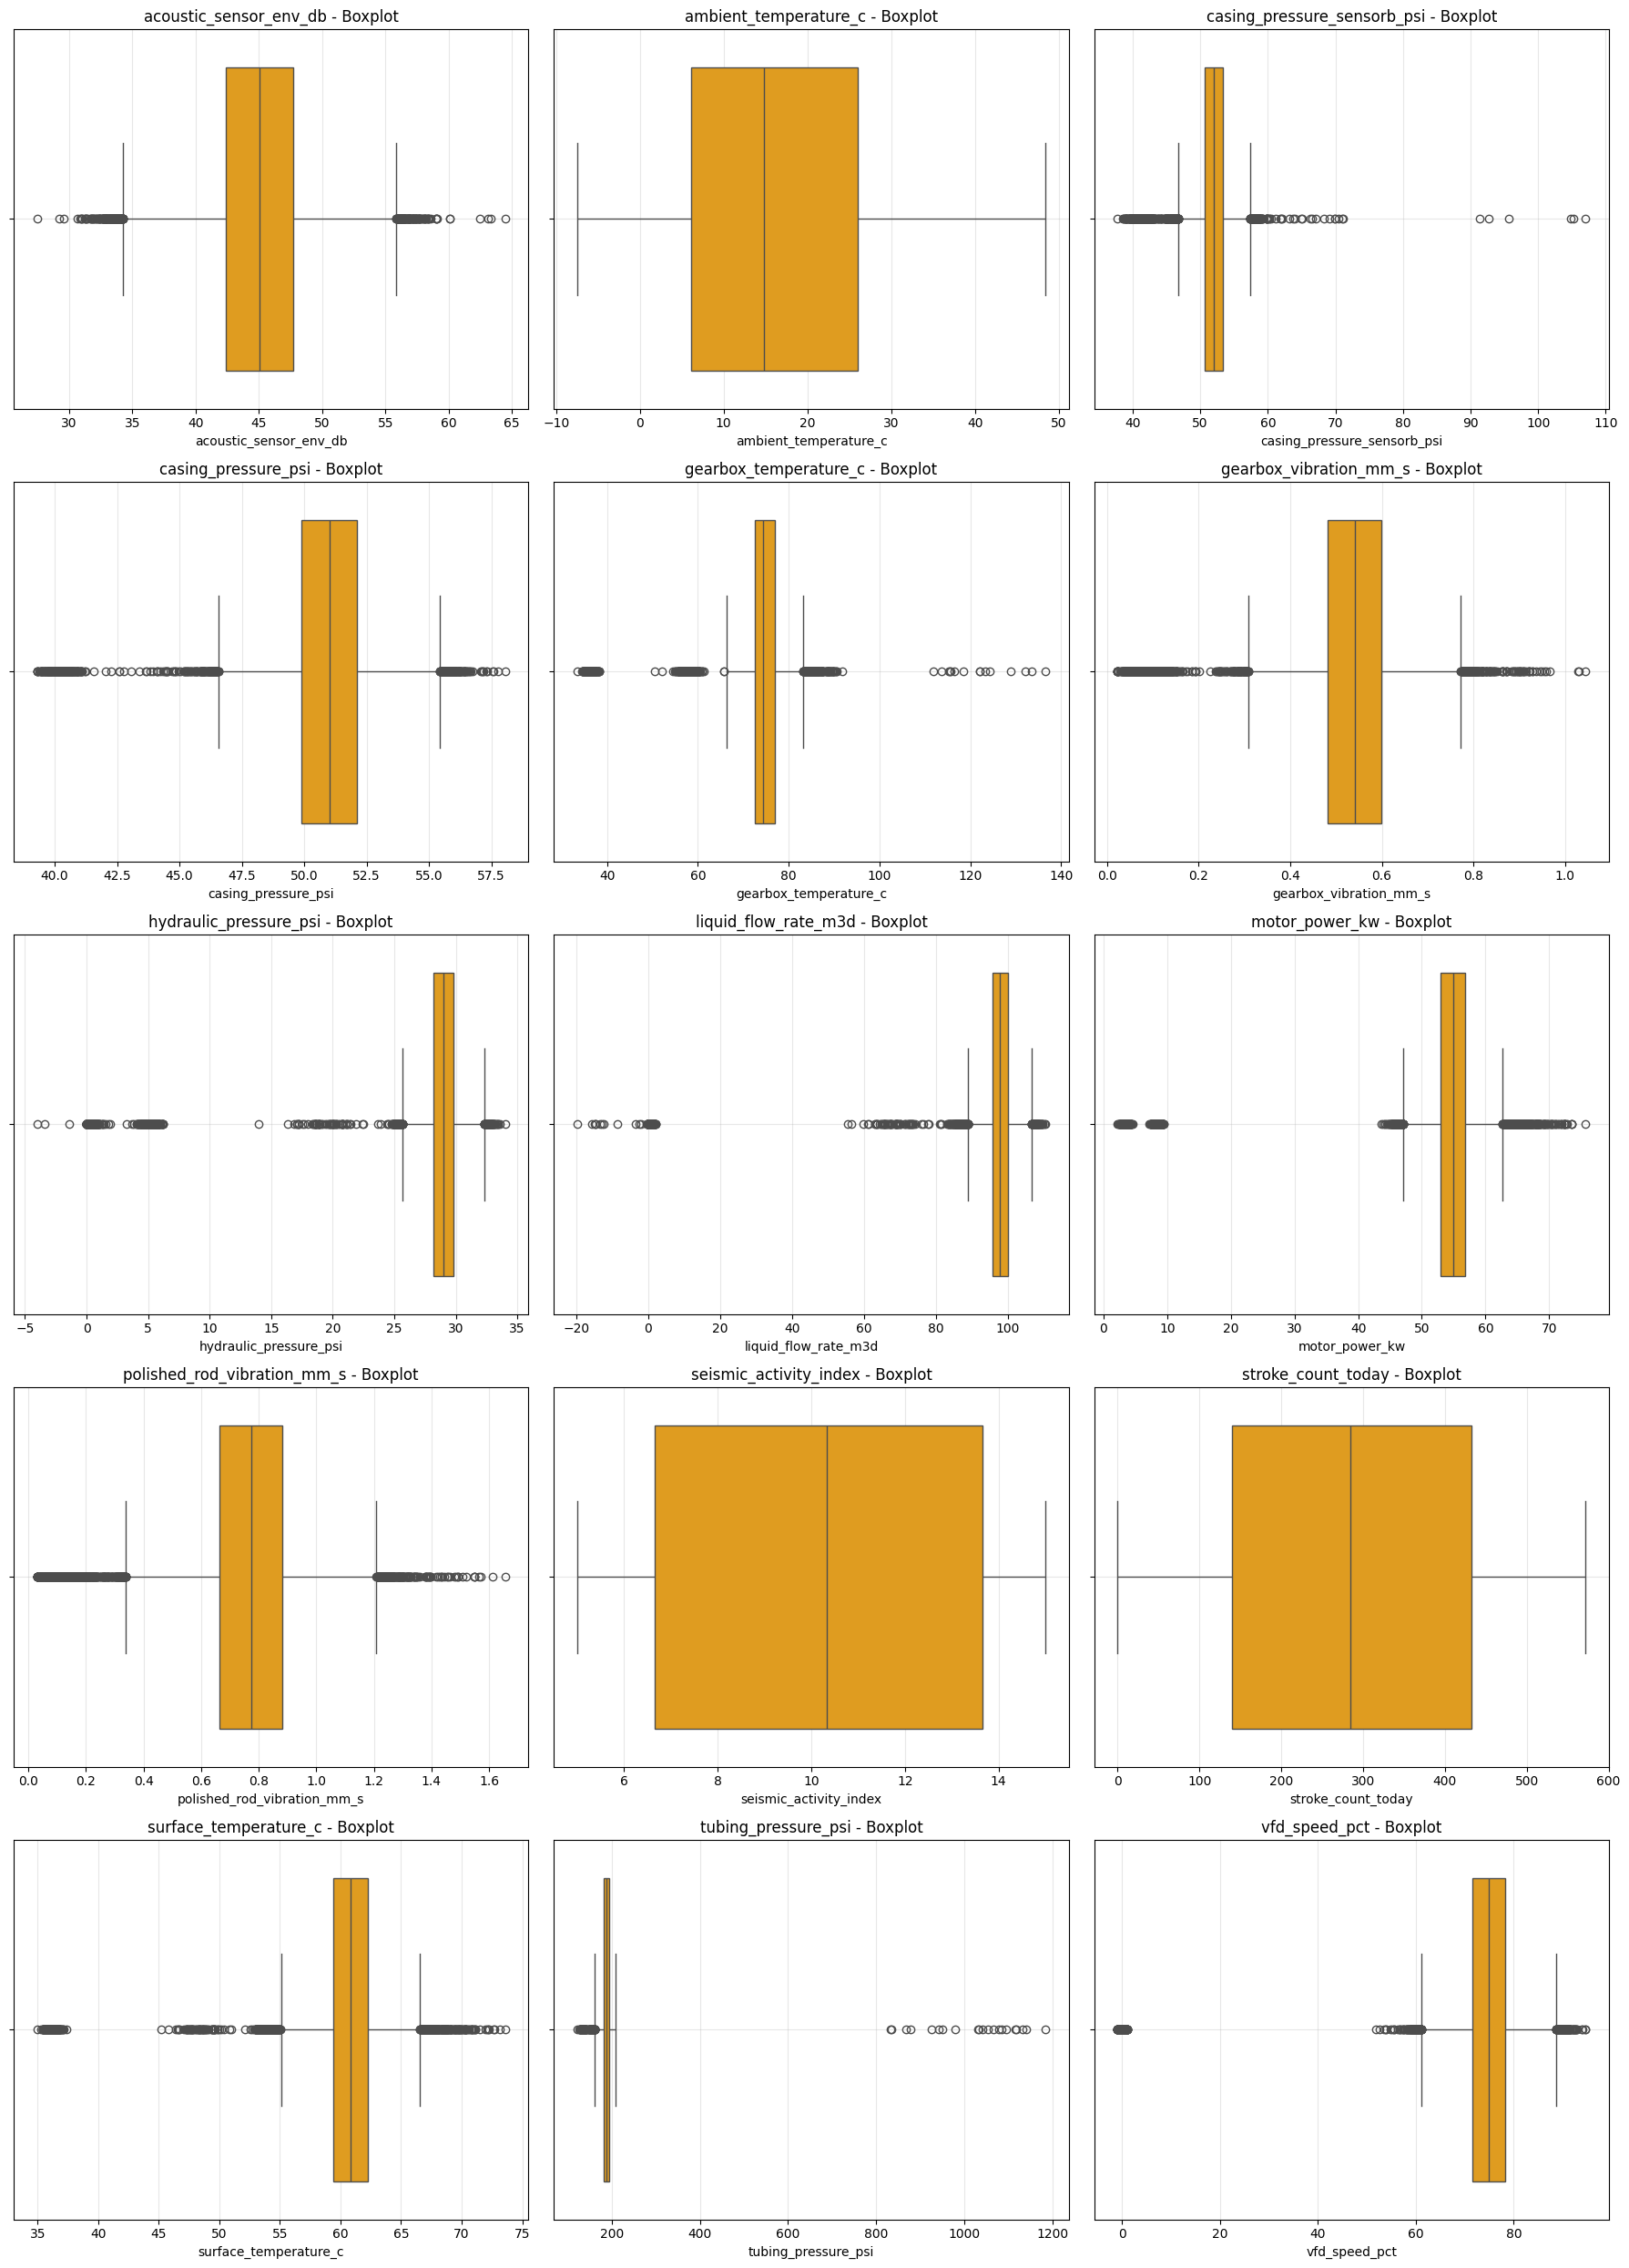

In [26]:
plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=df_num[col], color="orange")
    plt.title(f"{col} - Boxplot")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Outlier Analysis using Box Plots

The box plots provide a clear visualization of potential outliers for each sensor and numerical feature.

Here's a feature-by-feature interpretation based on the presence and nature of these outliers:

* **`acoustic_sensor_env_db`:**
    * **Outliers:** Yes, present on both the lower and upper ends.
    * **Interpretation:** There are readings significantly lower (below ~35 dB) and significantly higher (above ~65 dB) than the bulk of the acoustic sensor data. These could represent unusually quiet or loud environmental conditions.

* **`ambient_temperature_c`:**
    * **Outliers:** Minimal to no distinct outliers visible beyond the whiskers.
    * **Interpretation:** The ambient temperature readings appear to be relatively contained within a typical range, with no extreme deviations flagged as outliers 

* **`casing_pressure_sensorb_psi`:**
    * **Outliers:** Yes, numerous outliers are present exclusively on the **higher end**.
    * **Interpretation:** While the majority of readings are concentrated at very low pressures (near zero), there are many instances of significantly higher pressure readings (extending up to ~110 psi). Could indicate specific operational events.

* **`casing_pressure_psi`:**
    * **Outliers:** Yes, present on both the lower and upper ends, though they appear relatively symmetrical and not excessively far from the whiskers.
    * **Interpretation:** There are some pressure readings that are moderately lower (below ~42.5 psi) and higher (above ~57.5 psi) than the main cluster of data.

* **`gearbox_temperature_c` :**
    * **Outliers:** Yes, a few distinct outliers are visible on both the lower and upper ends, despite the main data being extremely concentrated.
    * **Interpretation:** The gearbox temperature is exceptionally stable. The outliers (e.g., below ~60°C and above ~80°C) are notable because the typical variation is so small. These few deviations warrant investigation as they are unusual for this sensor.

* **`gearbox_vibration_mm_s`:**
    * **Outliers:** Yes, numerous outliers are present exclusively on the **higher end**.
    * **Interpretation:** Typical gearbox vibration is low, but there are frequent instances of significantly higher vibration levels (extending up to ~1.3 mm/s). These high vibration events could be indicative of stress or developing issues.

* **`hydraulic_pressure_psi`:**
    * **Outliers:** Yes, outliers are present on both the lower (below ~20 psi) and upper (above ~30 psi) ends, despite the main data being very tightly clustered.
    * **Interpretation:** Similar to gearbox temperature, hydraulic pressure is very stable. The outliers represent deviations from this tight operational band and could be significant.

* **`liquid_flow_rate_m3d`:**
    * **Outliers:** The plot shows a very narrow IQR, suggesting the data is clustered around two main points (as seen in the histogram). Given this structure, the concept of "outliers" in the traditional box plot sense might be less informative here if the two modes are both considered normal operating states. However, if we consider the main cluster to be the higher flow state, then the values near zero might be considered a separate state rather than outliers. The plot doesn't show distinct points far from the two main clusters.
    * **Interpretation:** The box plot is compact, indicating data is clustered. The bimodal nature (seen in histograms) is more revealing than outlier points for this feature. The whiskers are short, and no points are shown far beyond them.

* **`motor_power_kw`:**
    * **Outliers:** Yes, outliers are present primarily on the **higher end**.
    * **Interpretation:** While the motor typically operates at lower power levels, there are instances of significantly higher power consumption (extending towards ~70 kW). These could correspond to high-load operations. Some minor outliers might also be on the lower end.

* **`polished_rod_vibration_mm_s`:**
    * **Outliers:** Yes, outliers are present on both the lower and, more prominently, on the **higher end**.
    * **Interpretation:** There are instances of both unusually low and, more frequently, unusually high polished rod vibrations compared to the typical range.

* **`seismic_activity_index`:**
    * **Outliers:** No distinct outliers are visible beyond the whiskers.
    * **Interpretation:** The U-shaped distribution seen in the histogram means the data is concentrated at the extremes of its range. The box plot reflects this by having whiskers that likely span the entire or most of the data range, thus not flagging individual points as outliers in the typical sense. The variability is inherent in the feature's nature.

* **`stroke_count_today`:**
    * **Outliers:** No distinct outliers are visible beyond the whiskers.
    * **Interpretation:** The data appears to be spread across its range without extreme values that stand far apart from the main distribution, consistent with the uniform-like distribution seen in histograms.

* **`surface_temperature_c`:**
    * **Outliers:** Yes, a few outliers are present on both the lower and upper ends.
    * **Interpretation:** There are some surface temperature readings that are colder or hotter than the typical operational range.

* **`tubing_pressure_psi`:**
    * **Outliers:** Yes, numerous and significant outliers are present exclusively on the **higher end**.
    * **Interpretation:** Tubing pressure is typically low, but there are many instances of substantially higher pressure events (extending to ~1200 psi). These are critical to note as they represent significant deviations.

* **`vfd_speed_pct`:**
    * **Outliers:** Yes, some outliers are visible, primarily on the **lower end** (values close to zero when the main operation is at higher speeds). There might be a few minor ones on the higher end as well, but the lower ones are more distinct from the main upper cluster.
    * **Interpretation:** When the VFD is operating (represented by the main box at higher percentages), there are some instances where the speed drops to unusually low values that are flagged as outliers relative to this main operating cluster. The cluster near 0% (seen in histograms) forms its own group.

**General Implications of Outlier Analysis:**
* Features with many outliers (especially one-sided like `casing_pressure_sensorb_psi`, `gearbox_vibration_mm_s`, `tubing_pressure_psi`) might indicate that these "extreme" events, while not the norm, are a regular characteristic of the system's operation or indicative of specific conditions that need to be modeled.
* For sensors with very stable readings and few, distinct outliers (e.g., `gearbox_temperature_c`, `hydraulic_pressure_psi`), these outliers could be highly significant events or potential sensor issues.
* The absence of outliers in features like `seismic_activity_index` or `stroke_count_today` reflects their inherent distributional characteristics (U-shaped or uniform, respectively).
* This outlier information is crucial for deciding on data cleaning strategies, feature scaling methods (robust scalers might be preferred), and for the feature engineering process, as these outliers might correlate with the `Monitoring_Alert` target.

#### 1.1.6. Bivariate Analysis: Feature Behavior during Alerts


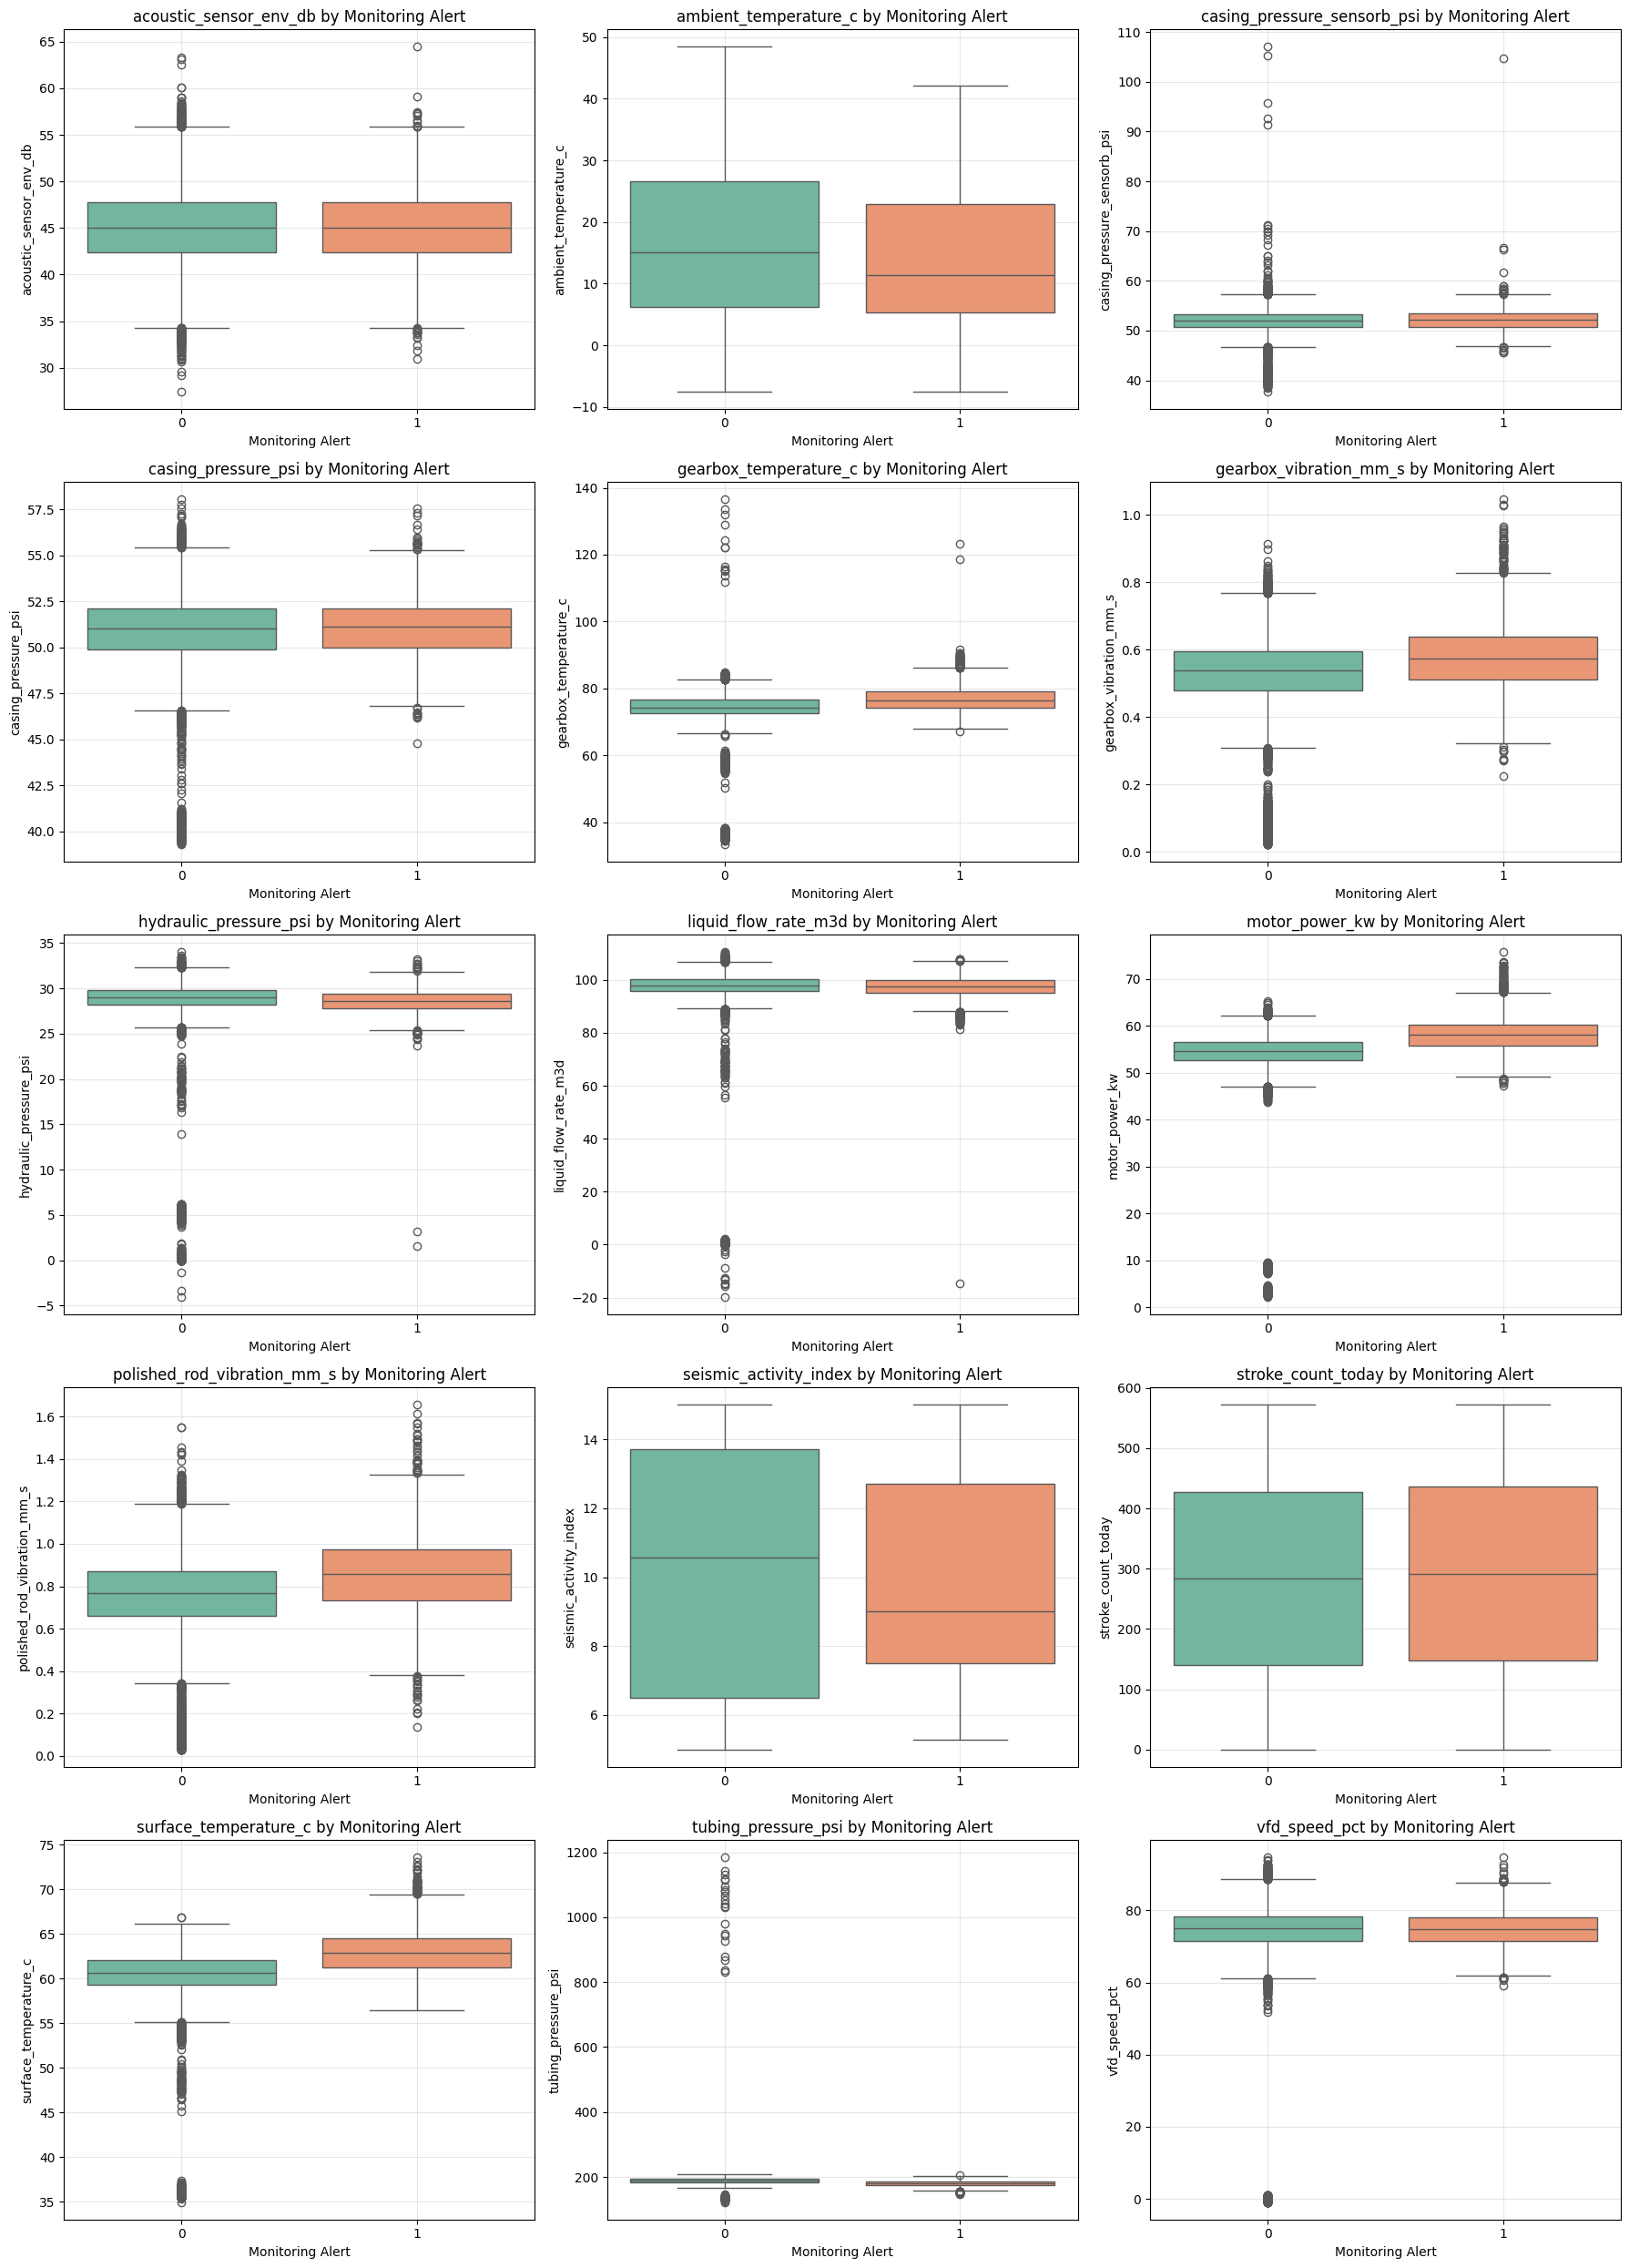

In [27]:
df_bi = train_df.select(["monitoring_alert"] + numerical_features).to_pandas()
df_bi["monitoring_alert"] = df_bi["monitoring_alert"].astype(str) 

num_cols = 3
num_rows = (len(numerical_features) + num_cols - 1) // num_cols
plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(data=df_bi, x="monitoring_alert", y=col, palette="Set2")
    plt.title(f"{col} by Monitoring Alert")
    plt.xlabel("Monitoring Alert")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* **`acoustic_sensor_env_db`**:
    * The median acoustic level appears **slightly higher** during alerts. The overall spread and interquartile range (IQR) are largely similar, suggesting a marginal increase in noise or sensor reading during alert events.

* **`ambient_temperature_c`**:
    * Ambient temperatures are noticeably **lower** during alerts. This suggests a strong correlation between lower ambient temperatures and alert conditions.

* **`casing_pressure_sensorb_psi`**:
    * Alerts predominantly occur when this sensor reads **slightly above zero**. Normal operations show readings tightly clustered at or very near zero. During alerts, the spread of readings is also wider, with more high-end outliers.

* **`casing_pressure_psi`**:
    * There's **no clear discernible difference** in the distribution of this casing pressure between normal and alert states.

* **`gearbox_temperature_c`**:
    * During alerts, the gearbox temperature shows a **wider spread and more outliers**, particularly on the higher side.

* **`gearbox_vibration_mm_s`**:
    * Gearbox vibration is significantly **higher** during alerts. Both the median and the upper range of vibrations (including the IQR and whiskers) are elevated when an alert is active.

* **`hydraulic_pressure_psi`**:
    * Hydraulic pressure exhibits a **wider range and more outliers (both high and low)** during alerts compared to its very tight clustering during normal operations. This indicates less stability in hydraulic pressure when an alert is present.

* **`liquid_flow_rate_m3d`**:
    * The liquid flow rate is predominantly **near zero** during alerts.

* **`motor_power_kw`**:
    * Motor power is generally **lower** during alerts, with a tighter distribution and a lower median. Normal operations exhibit a wider range of power consumption, including higher values not typically seen during active alerts.

* **`polished_rod_vibration_mm_s`**:
    * The median polished rod vibration appears **marginally higher** during alerts. The distribution also seems slightly more spread out towards higher vibration values when an alert is active.

* **`seismic_activity_index`**:
    * There's **no obvious difference** in the distribution of the seismic activity index between normal and alert conditions. Both states show a wide and similar spread of values across the index's range.

* **`stroke_count_today`**:
    * The daily stroke count tends to be **lower** during alerts. The median is lower, and the upper range of stroke counts (Q3 and upper whisker) is also reduced compared to normal operations.

* **`surface_temperature_c`**:
    * Surface temperature appears to be **slightly lower** during alerts, with its median and overall distribution shifted downwards compared to normal operations.

* **`tubing_pressure_psi`**:
    * Alerts are strongly associated with instances of **significantly higher** tubing pressure readings. The box plot for alerts is shifted to much higher values, and there are numerous high-end outliers during alerts that are not present in normal operations. This is a critical indicator.

* **`vfd_speed_pct`**:
    * VFD speed is predominantly **very low (near zero)** during alerts. Normal operations, while also showing some low-speed instances. This suggests alerts often occur when the VFD is off or running at minimal speed.

### Correlation Analysis of Numerical Features and Monitoring Alert

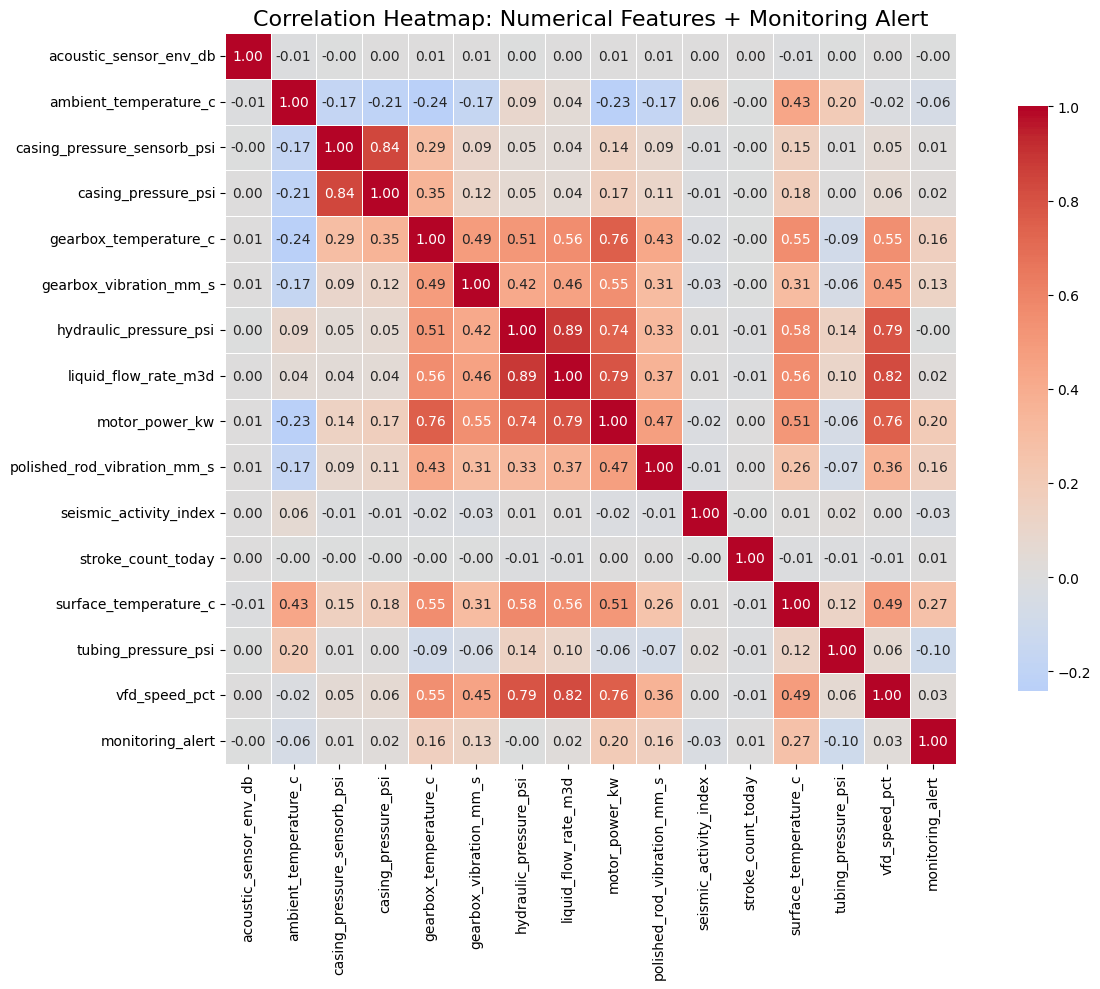

In [28]:
corr_matrix = df_bi[numerical_features + ["monitoring_alert"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})

plt.title("Correlation Heatmap: Numerical Features + Monitoring Alert", fontsize=16)
plt.tight_layout()
plt.show()


**Key Insights:**

- **Inter-Feature Correlations (Multicollinearity):**
    * **Strong Correlations:**
        * A significant block of features related to system activity show strong positive correlations with each other:
            * `hydraulic_pressure_psi` and `liquid_flow_rate_m3d` 
            * `hydraulic_pressure_psi` and `motor_power_kw` 
            * `liquid_flow_rate_m3d` and `motor_power_kw` 
            * `hydraulic_pressure_psi` and `vfd_speed_pct` 
            * `liquid_flow_rate_m3d` and `vfd_speed_pct` 
            * `motor_power_kw` and `vfd_speed_pct` 
            This suggests these sensors often move together and might represent different aspects of the same underlying operational intensity

**Implications for Modeling:**

* **Feature Importance:** Features with stronger correlations with `Monitoring_Alert` like `tubing_pressure_psi`, `ambient_temperature_c`, and `liquid_flow_rate_m3d` are good candidates for being important predictors.
* **Multicollinearity:** The high correlations between features in the "activity block" (hydraulic pressure, flow rate, motor power, VFD speed) and between the two casing pressure sensors mean there's some redundancy in the information they provide.
    * For linear models, high multicollinearity can make coefficient interpretation difficult and unstable.
    * Tree-based models are generally robust to multicollinearity,
    * Feature selection or dimensionality reduction could be considered if model performance is impacted or if a simpler model is desired, but it's often not strictly necessary for tree-based ensembles.

## 1.2. Feature Engineering & Preprocessing

In this step, we will:
1.  Engineer new features from existing data, primarily focusing on time-series aspects. This will be done using Polars for efficiency.
2.  Define a preprocessing pipeline using Scikit-learn to handle missing values, scale numerical features, and encode categorical features.
3.  Set up a time-aware data splitting strategy for model training and evaluation.

#### 1.2.1. Dropping Features
- **Rationale**
    - `Well_ID` is a constant term since the data corresponds to one well with ID = 101
    - As shown in 1.1.3 Missing Value Analysis, `maintenance_code`, `operational_notes`, `lubrication_status` has over ~85% data missing

In [29]:
train_df = drop_columns(train_df, ["well_id", "maintenance_code", "operational_notes", "lubrication_status"])
test_df = drop_columns(test_df, ["well_id", "maintenance_code", "operational_notes", "lubrication_status"])

#### 1.2.2 Handling Numeric Missing Values

- **Rationale**
    - As per 1.1.3 Missing Value Analysis, we will handle missing values according to strategies discussed below


| Feature Name                | Likely Cause           | Recommended Action    | Justification                                          |
|----------------------------|-------------------------|------------------------|--------------------------------------------------------|
| liquid_flow_rate_m3d       | Missing reading         | Impute (median)        | Continuous process variable; Important operational signal   |
| tubing_pressure_psi        | Missing reading | Impute (interpolate)   | Time-based trend makes interpolation viable            |
| gearbox_temperature_c      | Missing reading              | Impute (ffill)         | Time continuity allows forward fill                    |
| vfd_speed_pct              | Missing reading          | Impute (interpolate)   | Smooth continuous trend; interpolatable                |
| surface_temperature_c      | Missing reading         | Impute (median)        | Relatively stable metric; median suitable              |
| acoustic_sensor_env_db     | Missing reading  | Impute (median)          | data can have spikes or outliers. The median is robust to these                    |

#### Missing Data will be handled in Data Pre-processing Pipeline

In [30]:
# Imputation strategies based on earlier discussion
imputation_map = {
    "liquid_flow_rate_m3d": pl.col("liquid_flow_rate_m3d").fill_null(pl.median("liquid_flow_rate_m3d")),
    "tubing_pressure_psi": pl.col("tubing_pressure_psi").interpolate(),
    "gearbox_temperature_c": pl.col("gearbox_temperature_c").forward_fill(),
    "vfd_speed_pct": pl.col("vfd_speed_pct").interpolate(),
    "surface_temperature_c": pl.col("surface_temperature_c").fill_null(pl.median("surface_temperature_c")),
    "acoustic_sensor_env_db": pl.col("acoustic_sensor_env_db").fill_null(pl.median("acoustic_sensor_env_db")),
}

In [31]:
train_df_processed = handle_missing_values(train_df.clone(), imputation_map)

Applying imputation for: liquid_flow_rate_m3d
Applying imputation for: tubing_pressure_psi
Applying imputation for: gearbox_temperature_c
Applying imputation for: vfd_speed_pct
Applying imputation for: surface_temperature_c
Applying imputation for: acoustic_sensor_env_db


In [32]:
missing_values_analysis(train_df_processed)

column,dtype,missing_count,missing_pct
str,str,i64,f64


In [33]:
test_df_processed = handle_missing_values(test_df.clone(), imputation_map)

Applying imputation for: liquid_flow_rate_m3d
Applying imputation for: tubing_pressure_psi
Applying imputation for: gearbox_temperature_c
Applying imputation for: vfd_speed_pct
Applying imputation for: surface_temperature_c
Applying imputation for: acoustic_sensor_env_db


In [34]:
missing_values_analysis(test_df_processed)

column,dtype,missing_count,missing_pct
str,str,i64,f64


#### 1.2.3 Creating time-base features

**Rationale**

Timestamps on their own are just Datetime objects. To extract meaningful patterns, we break them into components.
* **Year, Month, Day, Weekday, Ordinal Day, Hour, Minute, Week, Quarter**

Think of timestamp as a container — we open it up to extract useful signal components.

In [35]:
train_df_processed = create_time_features(train_df_processed.clone())

Creating time-based features from column: timestamp
Time-based features created successfully.


In [36]:
test_df_processed = create_time_features(test_df_processed.clone())

Creating time-based features from column: timestamp
Time-based features created successfully.


#### 1.2.4 Encoding Categorical Variables

- Rationale
    - Make categorical values machine-readable.
    - Enable model to detect patterns or group effects.

In [37]:
train_df_processed = one_hot_encode_categorical(train_df_processed, categorical_columns=["well_operating_status"])

Performing one-hot encoding for columns: ['well_operating_status']
One-hot encoding completed successfully.


In [38]:
test_df_processed = one_hot_encode_categorical(test_df_processed, categorical_columns=["well_operating_status"])

Performing one-hot encoding for columns: ['well_operating_status']
One-hot encoding completed successfully.


In [39]:
train_df_processed.head()

well_operating_status_Maintenance,well_operating_status_Operating,well_operating_status_Standby,well_operating_status_Startup,acoustic_sensor_env_db,ambient_temperature_c,casing_pressure_sensorb_psi,casing_pressure_psi,gearbox_temperature_c,gearbox_vibration_mm_s,hydraulic_pressure_psi,liquid_flow_rate_m3d,motor_power_kw,polished_rod_vibration_mm_s,seismic_activity_index,stroke_count_today,surface_temperature_c,tubing_pressure_psi,vfd_speed_pct,monitoring_alert,timestamp_year,timestamp_month,timestamp_day_of_month,timestamp_day_of_week,timestamp_day_of_year,timestamp_hour,timestamp_minute,timestamp_week_of_year,timestamp_quarter
u8,u8,u8,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,i32,i8,i8,i8,i16,i8,i8,i8,i8
0,1,0,0,49.227346,38.854665,50.897459,49.25623,67.367428,0.517302,30.170903,100.76905,48.550611,0.931715,10.0,0,64.128805,197.273721,67.414439,0,2023,1,1,7,1,0,0,52,1
0,1,0,0,40.135114,36.311768,49.925884,48.734318,71.938489,0.481706,29.941944,99.845761,50.020863,0.612326,10.007173,4,64.625281,201.903168,86.075002,0,2023,1,1,7,1,0,10,52,1
0,1,0,0,51.190784,38.751977,50.518002,49.636435,73.476772,0.607282,30.457478,103.088886,54.098816,0.663035,10.014345,8,62.624781,198.521759,73.653432,0,2023,1,1,7,1,0,20,52,1
0,1,0,0,45.558002,40.66251,51.624718,50.175814,72.928716,0.634475,31.381904,101.08972,50.049383,0.79338,10.021518,12,64.064278,204.559909,74.619125,0,2023,1,1,7,1,0,30,52,1
0,1,0,0,45.064738,37.945231,52.292048,49.078709,68.188568,0.477692,29.95688,98.444687,50.211552,0.827998,10.02869,16,63.969226,202.119309,76.773574,0,2023,1,1,7,1,0,40,52,1


#### 1.2.5 Feature Scaling

- Rationale
    - In general sensor data from industrial pipelines have a lot of outliers that cannot be ignored. 
    - Without scaling, the model may learn to Overweight large-scale features and ignore others. This leads to struggle with convergence or unoptimized performance.

- We will use **RobustScaler** because:
    - StandardScaler & MinMaxScaler are sensitive to outliers. Just one extreme value can skew the entire scaling.

    - RobustScaler is more robust in real-world data where outliers exist.

In [40]:
columns_to_scale = ['acoustic_sensor_env_db',
 'ambient_temperature_c',
 'casing_pressure_sensorb_psi',
 'casing_pressure_psi',
 'gearbox_temperature_c',
 'gearbox_vibration_mm_s',
 'hydraulic_pressure_psi',
 'liquid_flow_rate_m3d',
 'motor_power_kw',
 'polished_rod_vibration_mm_s',
 'seismic_activity_index',
 'stroke_count_today',
 'surface_temperature_c',
 'tubing_pressure_psi',
 'vfd_speed_pct'
 ]

train_df_processed, fitted_scaler = scale_features_robust(
    df=train_df_processed,
    columns_to_scale=columns_to_scale,
    scaler_object=None  # fit on training data
)

Applied scikit-learn RobustScaler to columns: ['acoustic_sensor_env_db', 'ambient_temperature_c', 'casing_pressure_sensorb_psi', 'casing_pressure_psi', 'gearbox_temperature_c', 'gearbox_vibration_mm_s', 'hydraulic_pressure_psi', 'liquid_flow_rate_m3d', 'motor_power_kw', 'polished_rod_vibration_mm_s', 'seismic_activity_index', 'stroke_count_today', 'surface_temperature_c', 'tubing_pressure_psi', 'vfd_speed_pct']


In [41]:
test_df_processed, _ = scale_features_robust(
    df=test_df_processed,
    columns_to_scale=columns_to_scale,
    scaler_object=fitted_scaler  # transform test data with the same scaler
)

Applied scikit-learn RobustScaler to columns: ['acoustic_sensor_env_db', 'ambient_temperature_c', 'casing_pressure_sensorb_psi', 'casing_pressure_psi', 'gearbox_temperature_c', 'gearbox_vibration_mm_s', 'hydraulic_pressure_psi', 'liquid_flow_rate_m3d', 'motor_power_kw', 'polished_rod_vibration_mm_s', 'seismic_activity_index', 'stroke_count_today', 'surface_temperature_c', 'tubing_pressure_psi', 'vfd_speed_pct']


In [42]:
train_df_processed.head()

well_operating_status_Maintenance,well_operating_status_Operating,well_operating_status_Standby,well_operating_status_Startup,acoustic_sensor_env_db,ambient_temperature_c,casing_pressure_sensorb_psi,casing_pressure_psi,gearbox_temperature_c,gearbox_vibration_mm_s,hydraulic_pressure_psi,liquid_flow_rate_m3d,motor_power_kw,polished_rod_vibration_mm_s,seismic_activity_index,stroke_count_today,surface_temperature_c,tubing_pressure_psi,vfd_speed_pct,monitoring_alert,timestamp_year,timestamp_month,timestamp_day_of_month,timestamp_day_of_week,timestamp_day_of_year,timestamp_hour,timestamp_minute,timestamp_week_of_year,timestamp_quarter
u8,u8,u8,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,i8,i8,i8,i16,i8,i8,i8,i8
0,1,0,0,0.782314,1.203997,-0.428621,-0.790526,-1.663871,-0.198154,0.708719,0.662451,-1.63193,0.725259,-0.047144,-0.972603,1.174924,0.768735,-1.10553,0,2023,1,1,7,1,0,0,52,1
0,1,0,0,-0.920726,1.076664,-0.794577,-1.025774,-0.589335,-0.504489,0.571005,0.44661,-1.256653,-0.745154,-0.046118,-0.958904,1.350771,1.133693,1.635671,0,2023,1,1,7,1,0,10,52,1
0,1,0,0,1.15008,1.198855,-0.571548,-0.619151,-0.227725,0.576192,0.881087,1.204768,-0.215771,-0.5117,-0.045093,-0.945205,0.642212,0.867123,-0.189034,0,2023,1,1,7,1,0,20,52,1
0,1,0,0,0.095019,1.294523,-0.154689,-0.376029,-0.356558,0.810203,1.437109,0.737415,-1.249374,0.088387,-0.044067,-0.931507,1.152069,1.343135,-0.047176,0,2023,1,1,7,1,0,30,52,1
0,1,0,0,0.002627,1.158458,0.09667,-0.870542,-1.470843,-0.539034,0.579989,0.119075,-1.207981,0.247761,-0.043042,-0.917808,1.118402,1.150732,0.269309,0,2023,1,1,7,1,0,40,52,1


#### 1.2.6 Feature Lag

- To capture any temporal dependencies — how the past sensor values affect the present or future.
- We chose Lag Time as 10 minutes ago, 20 minutes ago, 30 minutes ago, 1 hour ago, 2 hours ago, 1 day ago

**Trade-Off**
- Model complexity: More lags = more features = risk of overfitting.

In [43]:
lag_steps = [1, 2, 3, 6, 12, 144]

train_df_processed = create_lagged_features(train_df_processed, lag_steps=lag_steps, features=numerical_features)
test_df_processed = create_lagged_features(test_df_processed, lag_steps=lag_steps, features=numerical_features)

In [44]:
test_df_processed.shape

(10053, 118)

### 1.3. Modelling

- In this section, we develop and validate ML model to predict operational alerts based on historical sensor and environmental data. 

- We begin by splitting the dataset into training and validation sets, then establish a baseline for comparison. 
- We then perform model training and evaluation
- Followed by model interpretation through feature importance and explainability tools.

#### 1.3.1. Training Validation Split
We split the available training dataset into two subsets: a training set and a validation set. 

- Allows us to tune and evaluate model performance before final testing. Since the test set is held out for final evaluation, we avoid data leakage and ensure more robust model validation.

In [45]:
TARGET_COLUMN = "monitoring_alert"

try:
    feature_columns = [col for col in train_df_processed.columns if col != TARGET_COLUMN]

    X = train_df_processed.select(feature_columns)
    y = train_df_processed.select(TARGET_COLUMN).to_numpy().ravel()

    X_pd = X.to_pandas()

    X_train, X_val, y_train, y_val = train_test_split(X_pd, y, test_size=0.2, random_state=42)

    print(f"Shape of X_train: {X_train.shape}")
    print(f"Shape of y_train: {y_train.shape}")
    print(f"Shape of X_val: {X_val.shape}")
    print(f"Shape of y_val: {y_val.shape}")
    print(f"Unique classes in y_train: {np.unique(y_train, return_counts=True)}")

except Exception as e:
    print(f"Error preparing data: {e}")
    print("Ensure your DataFrames (train_df_scaled, test_df_scaled) and TARGET_COLUMN are correctly defined.")
    raise

Shape of X_train: (32514, 118)
Shape of y_train: (32514,)
Shape of X_val: (8129, 118)
Shape of y_val: (8129,)
Unique classes in y_train: (array([0, 1]), array([29410,  3104]))


- As noted earlier, our dataset has an imbalance since Monitoring Alerts (=1) will be rare. We will take this into account while selecting our final model for prediction

#### 1.3.2. Baseline Modeling

- To establish a reference performance metric, we will train a baseline model.
- All subsequent models must outperform this baseline to be considered useful.

In [46]:
# Instantiate dummy classifier (most frequent class strategy)
baseline_clf = DummyClassifier(strategy="most_frequent", random_state=42)

baseline_clf.fit(X_train, y_train)
y_pred_baseline = baseline_clf.predict(X_val)

Accuracy:  0.9052
Precision (for class 1): 0.0000
Recall (for class 1):    0.0000
F1-score (for class 1):  0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      7358
           1       0.00      0.00      0.00       771

    accuracy                           0.91      8129
   macro avg       0.45      0.50      0.48      8129
weighted avg       0.82      0.91      0.86      8129


Confusion Matrix:
[[7358    0]
 [ 771    0]]


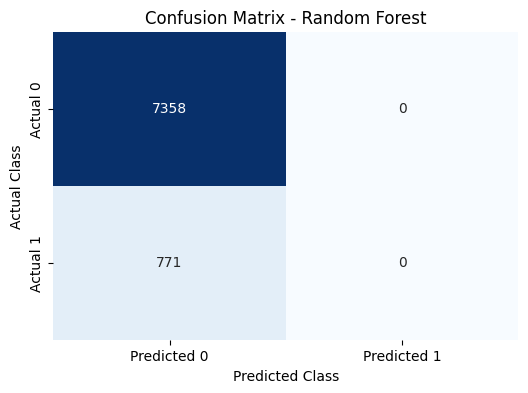

In [47]:
evaluate_model(
    y_val=y_val,
    y_pred_test_rf=y_pred_baseline,
    plot_cm=True,
)

- Now that we have our baseline, which is absolutely **abysmal**, we will use `RandomForestClassifier` to find some performance

#### 1.3.3. Model Training

I have chosen a Random Forest model for our dataset. 
- **Rationale**
    - Random Forest is a robust ensemble method well-suited for tabular data.
    - It handles non-linear relationships and provides inherent feature importance.
    - It is robust to Noise and Outliers
    - Works Well with Mixed Feature Types

In [48]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,       
    random_state=42,        
    class_weight='balanced', # Adjusts weights inversely proportional to class frequencies
    n_jobs=-1 # Allows the model to use all avaialble cores
)

print("\nTraining Random Forest Classifier...")
try:
    rf_classifier.fit(X_train, y_train)
    print("Training complete.")
except Exception as e:
    print(f"Error during model training: {e}")
    raise


Training Random Forest Classifier...
Training complete.


#### 1.3.4. Model Evaluation

- The trained model is evaluated on the validation dataset using performance metrics.
- Helps assess generalization performance and compare it with the baseline.

In [49]:
print("\nMaking predictions on the Validation set...")
try:
    y_pred_test_rf = rf_classifier.predict(X_val)
    y_proba_test_rf = rf_classifier.predict_proba(X_val)[:, 1] # Probabilities for the positive class (1)
    print("Predictions made.")
except Exception as e:
    print(f"Error during prediction: {e}")
    raise


Making predictions on the Validation set...
Predictions made.


Accuracy:  0.9856
Precision (for class 1): 0.9955
Recall (for class 1):    0.8521
F1-score (for class 1):  0.9182
ROC AUC Score: 0.9980

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7358
           1       1.00      0.85      0.92       771

    accuracy                           0.99      8129
   macro avg       0.99      0.93      0.96      8129
weighted avg       0.99      0.99      0.99      8129


Confusion Matrix:
[[7355    3]
 [ 114  657]]


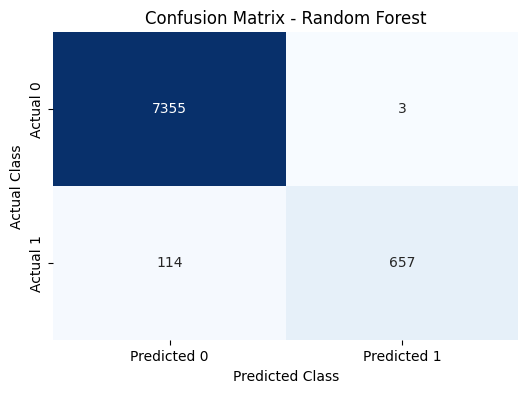

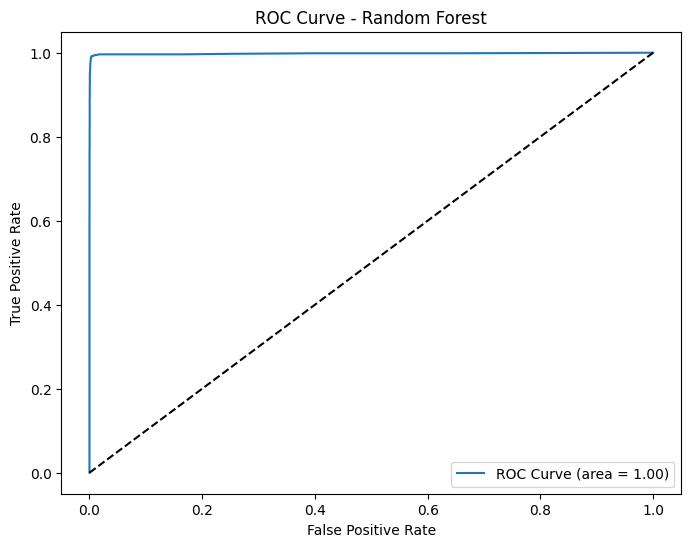

In [50]:
evaluate_model(
    y_val=y_val,
    y_pred_test_rf=y_pred_test_rf,
    y_proba_test_rf=y_proba_test_rf,
    plot_cm=True,
    plot_roc_curve=True,
)

**Classifier Performance Summary**

- The model excellent overall performance on the validation set, achieving an accuracy of 98.55%, which indicates that the model correctly classifies the vast majority of instances.

- Precision for the positive class (1) is very high at 99.54%, meaning that when the model predicts class 1, it is correct almost all the time — very few false positives.

- Recall for the positive class (1) is 85.08%, indicating that the model successfully identifies 85% of the true positive cases, though it misses about 15% (false negatives). Room for improvement depending on the application’s tolerance.

- The ROC AUC score of 0.998 suggests the model has excellent ability to distinguish between classes across all classification thresholds.

- The classification report shows that the model performs almost perfectly for the negative class (class 0) with near-perfect precision and recall, while for the positive class (class 1) it achieves perfect precision but somewhat lower recall.

- We can also conclude based on metrics that our model is not overfitting.

Insights: 

**The model is highly precise and accurate overall, with a slight tendency to miss some positive cases. Given our use case, we should consider tuning the model or threshold to improve recall since missing positive cases can be costly.

#### 1.3.5. RandomForest Classifier Fine Tuning

In [51]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

In [52]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  16.5s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  16.6s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  16.6s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  16.8s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  17.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  32.3s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  32.4s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  32.7s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  32.9s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  33.1s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=  15.7s
[CV] END max_depth=10, min_samples_split=5, n_e

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=2)

In [53]:
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}


#### 1.3.6. Hyperparameter-Tuned Model Evaluation

- The tuned model is evaluated again on the validation dataset to check our recall.

In [54]:
print("\nMaking predictions on the Validation set...")
try:
    y_pred_test_rf = best_rf.predict(X_val)
except Exception as e:
    print(f"Error during prediction: {e}")
    raise


Making predictions on the Validation set...


Accuracy:  0.9882
Precision (for class 1): 0.9927
Recall (for class 1):    0.8820
F1-score (for class 1):  0.9341

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7358
           1       0.99      0.88      0.93       771

    accuracy                           0.99      8129
   macro avg       0.99      0.94      0.96      8129
weighted avg       0.99      0.99      0.99      8129


Confusion Matrix:
[[7353    5]
 [  91  680]]


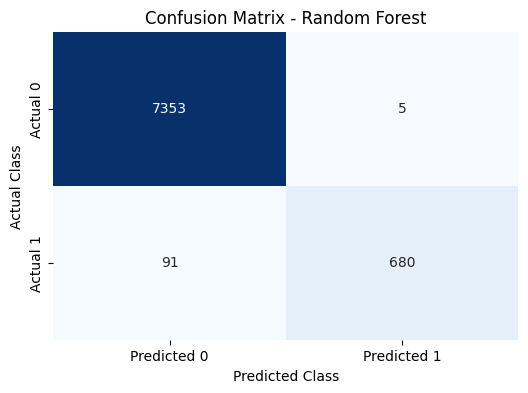

In [55]:
evaluate_model(
    y_val=y_val,
    y_pred_test_rf=y_pred_test_rf,
    plot_cm=True,
)

**Key Takeaways:**
- We improved recall while maintaining precision and overall accuracy.
- This was important since class 1 represents critical events, where false negatives are costly.
- The model is now better at catching more anomalies, even if it slightly increased the chance of false positives.

#### 1.3.7. Feature Importance & Explainability

- Performimg feature importance to understand which variables most influence the model's predictions.
- Supports model transparency, interpretability, and potential regulatory compliance.



Plotting Gini Importance (RF)...


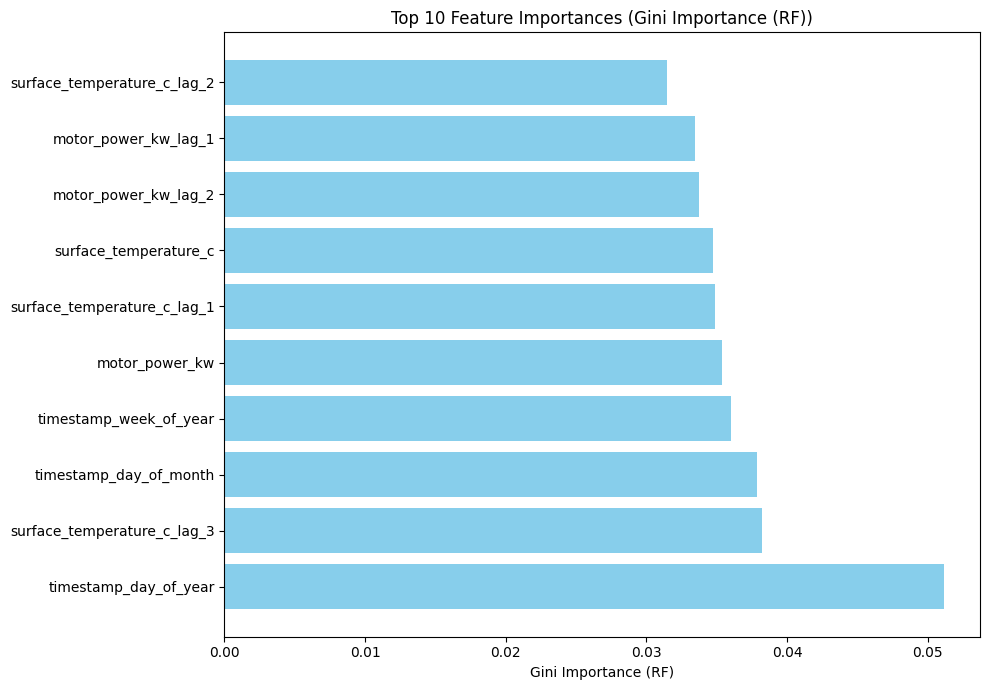


Calculating and Plotting Permutation Importances...


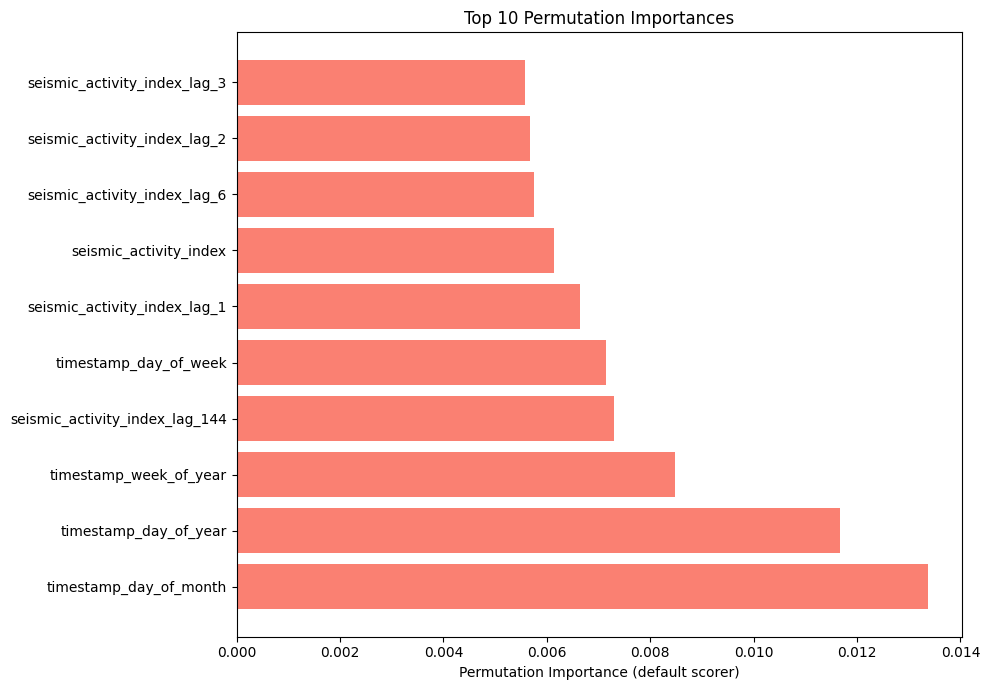

In [56]:
run_feature_importance_analysis(
    model=rf_classifier,
    X_val=X_val,
    y_val=y_val,
    top_n=10,
    tree_importance_type_name="Gini Importance (RF)"
)

**Feature Importance Insights**

- Top 10 Feature Importances (Gini Importance)
    - Based on Gini impurity in Random Forest splits.
        - **Key points:**
        - Dominance of sensor data & short-term lags:
            - `surface_temperature_c` + short lags (`lag_1`, `lag_2`, `lag_3`) are top features.
            - `motor_power_kw` + short lags (`lag_1`, `lag_2`) also rank highly.
        - Temporal features matter:
            - `timestamp_day_of_year` is most important.
            - `timestamp_day_of_month` & `timestamp_week_of_year` also appear in top 10.
        - **Interpretation:** Model relies heavily on immediate sensor data and seasonality/time cycles.

- Top 10 Permutation Importances
  - Measures impact on model score when a feature is shuffled.
    - **Key points:**
      - Seismic activity dominates:
        - Multiple lags of `seismic_activity_index` (e.g., `lag_2`, `lag_3`, `lag_144`) are top.
        - Current `seismic_activity_index` is important.
      - Temporal features remain important:
        - `timestamp_day_of_month` ranks highest here.
      - Sensor readings like `surface_temperature` and `motor_power` are absent from top 10.

* Key Takeaways
  - Gini importance: reflects feature contribution during tree splits.
  - Permutation importance: reflects feature impact on model predictive accuracy.
  - Differences arise due to:
    - Correlated features possibly inflating Gini scores.
  - **Actionable conclusions:**
    - Temporal context is crucial.
    - Seismic data strongly influences prediction accuracy.

**Summary:**  
Model uses temperature & power mainly, but seismic activity and time-based features drive predictive accuracy

**Saving the Selected Model**

In [57]:
#saving model as pkl in /models directory
model_path = "models/random_forest_classifier.pkl"
joblib.dump(best_rf, model_path)
print(f"Model saved to {model_path}")


Model saved to models/random_forest_classifier.pkl


#### 1.3.8. Model Validation
Important to validate the robustness of the trained model

- We will perform cross-validation using `StratifiedKFold` (ensures that each fold of the cross-validation preserves the same proportion of each class as in the original dataset). 
    - Ensures the model performs consistently across different subsets of the data and avoids overfitting

In [58]:
# Using best selected parameters
rf_cv = RandomForestClassifier(
    n_estimators=200, 
    max_depth=30, 
    n_jobs=-1,
    min_samples_leaf=2,
    random_state=42
)
perform_cross_validation(model=rf_cv, X=X_train, y=y_train, scoring='f1', n_splits=5)

Cross-validation f1 scores: [0.92387543 0.8969163  0.91616249 0.9220104  0.89716312]
Mean f1 score: 0.9112
Standard deviation: 0.0119


array([0.92387543, 0.8969163 , 0.91616249, 0.9220104 , 0.89716312])

**Key Insights:**

- 5-fold scores are around 0.90 to 0.92, showing consistent strong performance.

- The mean F1 score of ~0.911 means the model achieves a good balance of precision and recall on average across folds.

- The low standard deviation (~0.0119) shows the model’s performance is stable and reliable across different splits of the data (not overfitting to just some folds).

#### 1.3.9. Model Prediction on Test Data

- Selecting the best Threshold is important to us since we do not want to miss any monitoring_alert positive events.

* The threshold is the cutoff probability to decide whether to classify a data point as positive (1) or negative (0).
    - Lower (<0.5) Threshold means more data points classified as positive (1) increasing Recall
    - Higher (>0.5)	Threshold means fewer points classified as positive	decreasing Recall

- Rationale:
    - In a production system setting, missing positives is costly, so we need to select threshold that increases the overall F1-score.
    - Threshold adjustment is a tradeoff between Precision and Recall.

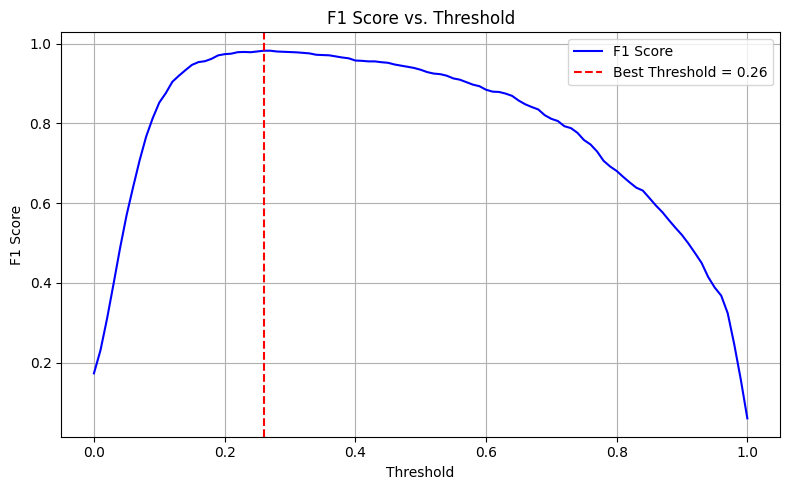

Best threshold: 0.26 with F1 score: 0.9825


In [59]:
model_path = "models/random_forest_classifier.pkl"
rf_classifier = joblib.load(model_path)

val_probs = rf_classifier.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = [f1_score(y_val, val_probs >= t) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]


plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, label='F1 Score', color='blue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.title('F1 Score vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best threshold: {best_threshold:.2f} with F1 score: {best_f1:.4f}")

In [90]:
X_test = test_df_processed.to_pandas()
test_probs = rf_classifier.predict_proba(X_test)[:, 1]
adjusted_preds = (test_probs >= best_threshold).astype(int)

results_df = test_df_processed.with_columns([
    pl.Series("predicted_monitoring_alert", adjusted_preds)
])

output_dir = "pred_output"
os.makedirs(output_dir, exist_ok=True)

output_file = f"model_predictions_threshold_{best_threshold*int(100)}.csv"
results_df.write_csv(os.path.join(output_dir, output_file))

print(f"Predictions saved to {os.path.join(output_dir, output_file)}")

Predictions saved to pred_output/model_predictions_threshold_26.0.csv



Monitoring Alert Distribution:
shape: (2, 2)
┌────────────────────────────┬───────┐
│ predicted_monitoring_alert ┆ count │
│ ---                        ┆ ---   │
│ i64                        ┆ u32   │
╞════════════════════════════╪═══════╡
│ 0                          ┆ 5021  │
│ 1                          ┆ 5032  │
└────────────────────────────┴───────┘


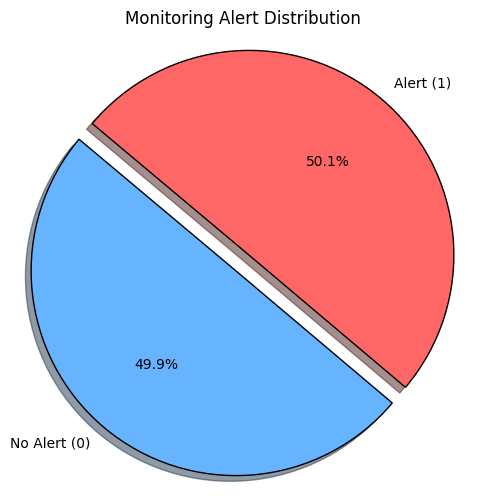

In [88]:
target_col = 'predicted_monitoring_alert'

alert_counts = results_df[target_col].value_counts().sort(target_col)
print("\nMonitoring Alert Distribution:")
print(alert_counts)

alert_counts_pd = alert_counts.to_pandas()

# Map actual classes present to readable labels
label_map = {0: 'No Alert (0)', 1: 'Alert (1)'}
present_classes = alert_counts_pd[target_col].tolist()
labels = [label_map[i] for i in present_classes]

sizes = alert_counts_pd['count']
colors = ['#66b3ff', '#ff6666']
explode = (0, 0.1)

plt.figure(figsize=(6, 6))
plt.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    startangle=140, colors=colors, explode=explode,
    shadow=True, wedgeprops={'edgecolor': 'black'}
)
plt.title('Monitoring Alert Distribution')
plt.axis('equal')
plt.show()

## Part 2: Health Monitoring - Early Warning System

**Objectives**:
- Detect operational anomalies that precede critical monitoring alerts, allowing for proactive intervention and optimized system health.
- Improving the anomaly detection model’s accuracy and robustness for reliable early warning.

### 2.1. Anamoly Detection using Isolation Forest

- Rationale
    - Isolates anomalies quickly since they are few and different from normal data.
    - Works without labels and is fast on high-dimensional data.
    - Provides a good baseline model.
    - It handles large datasets with tunable parameters for different anomaly rates.

In [91]:
X = train_df_processed.drop("monitoring_alert").to_numpy()
true_labels = train_df_processed["monitoring_alert"].to_numpy()

iso_forest = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X)

# Get anomaly scores (flip sign to make higher = more anomalous)
anomaly_scores = -iso_forest.decision_function(X)

# Add anomaly scores to back to dataFrame
train_df_processed = train_df_processed.with_columns(
    pl.Series("anomaly_score", anomaly_scores)
)

# Using 95th percentile as threshold for anomalies (top 5%)
threshold = np.percentile(anomaly_scores, 95)

train_df_processed = train_df_processed.with_columns(
    (pl.col("anomaly_score") > threshold).cast(pl.Int8).alias("predicted_anomaly")
)

predicted_labels = train_df_processed["predicted_anomaly"].to_numpy()
print(classification_report(true_labels, predicted_labels, target_names=["Normal", "Anomaly"]))

              precision    recall  f1-score   support

      Normal       0.91      0.96      0.94     36768
     Anomaly       0.25      0.13      0.17      3875

    accuracy                           0.88     40643
   macro avg       0.58      0.55      0.55     40643
weighted avg       0.85      0.88      0.86     40643



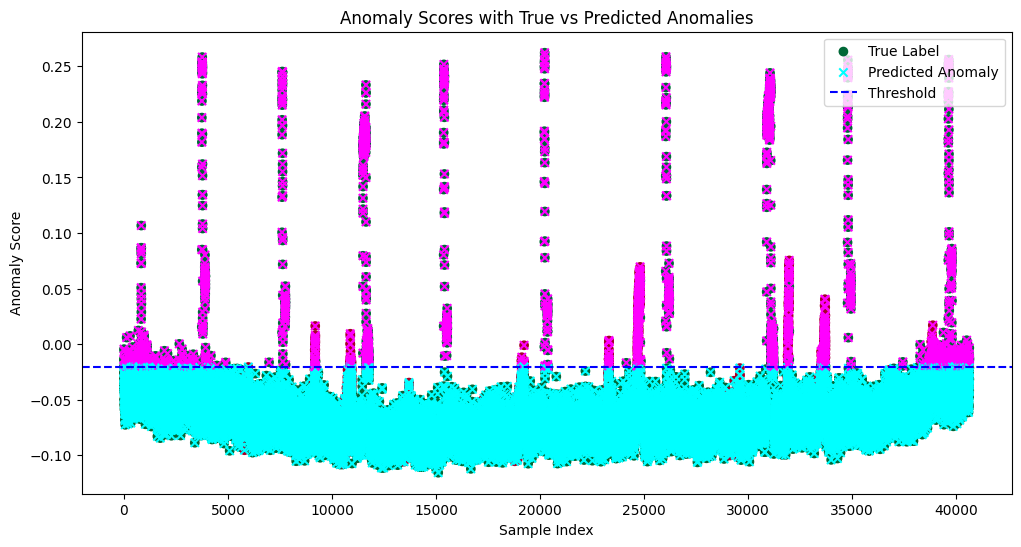

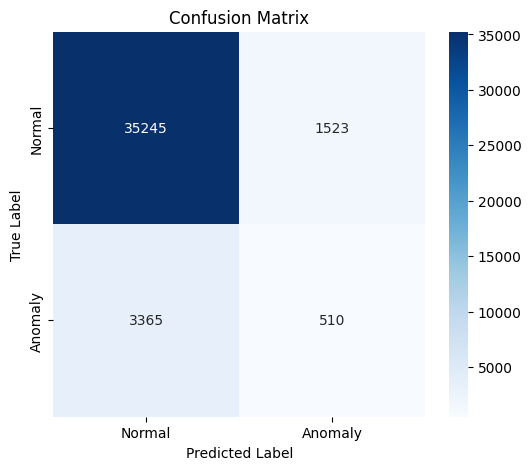

Number of anomalies detected: 2033


In [92]:
# Scatter plot of anomaly scores with true vs predicted labels
plt.figure(figsize=(12,6))
indices = range(len(anomaly_scores))
plt.scatter(indices, anomaly_scores, c=true_labels, cmap='RdYlGn_r', label='True Label', marker='o')
plt.scatter(indices, anomaly_scores, c=predicted_labels, cmap='cool', label='Predicted Anomaly', marker='x')
plt.axhline(threshold, color='blue', linestyle='--', label='Threshold')
plt.title('Anomaly Scores with True vs Predicted Anomalies')
plt.xlabel('Sample Index')
plt.ylabel('Anomaly Score')
plt.legend(loc='upper right')
plt.show()

# Confusion Matrix heatmap
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

num_anomalies = train_df_processed.filter(pl.col("predicted_anomaly") == 1).height
print(f"Number of anomalies detected: {num_anomalies}")


**Key Takeaways:**
- The model is very good at recognizing normal data but poor at detecting anomalies.
- The imbalance and model tuning probably cause many anomalies to be missed or mislabeled.
- High false negatives (missed anomalies) are critical
- The current threshold or model parameters may not be ideal for catching anomalies.

### 2.2. Hyperparameter and Threshold Tuning
- To improve the performance of our Anamoly Detection model we will try to select the best Threshold and Hyperparameter sets that results in higher F1-Score essentially increasing our Recall
- This shold help us catch anamolous events better.

### 2.2.1. Threshold Tuning

In [93]:
percentiles = list(range(80, 100))
f1_scores = []
precisions = []
recalls = []

for perc in percentiles:
    threshold = np.percentile(anomaly_scores, perc)
    preds = (anomaly_scores > threshold).astype(int)
    
    f1 = f1_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    
    f1_scores.append(f1)
    precisions.append(precision)
    recalls.append(recall)


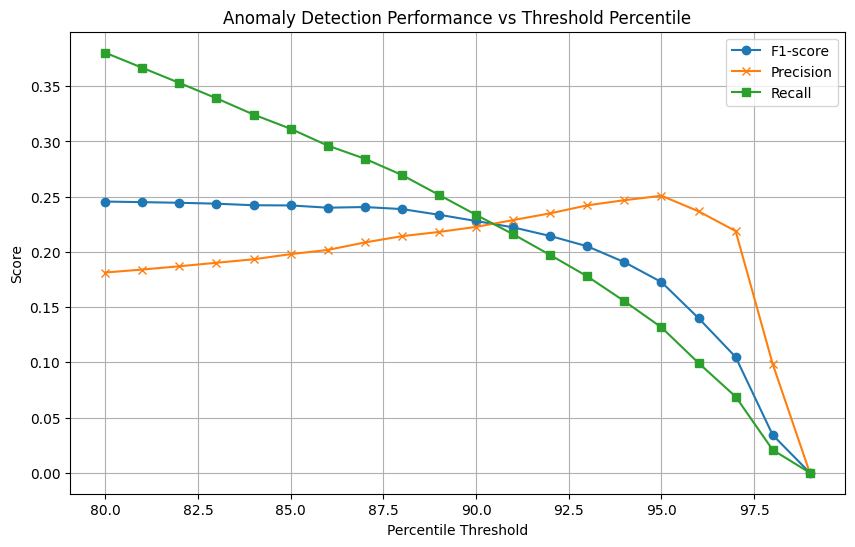

Best percentile threshold: 80%
F1-score: 0.2456, Precision: 0.1813, Recall: 0.3804


In [94]:
# Plot F1-score vs percentile threshold
plt.figure(figsize=(10, 6))
plt.plot(percentiles, f1_scores, label='F1-score', marker='o')
plt.plot(percentiles, precisions, label='Precision', marker='x')
plt.plot(percentiles, recalls, label='Recall', marker='s')
plt.xlabel('Percentile Threshold')
plt.ylabel('Score')
plt.title('Anomaly Detection Performance vs Threshold Percentile')
plt.legend()
plt.grid(True)
plt.show()

# Best percentile by F1-score
best_idx = np.argmax(f1_scores)
print(f"Best percentile threshold: {percentiles[best_idx]}%")
print(f"F1-score: {f1_scores[best_idx]:.4f}, Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

### 2.2.2. Hyperparameter Tuning with GridSearchCV

- We define a custom `f1_scorer` method since it allows us to use supervised metrics like F1 to tune unsupervised models.

In [95]:
X = train_df_processed.drop("monitoring_alert").to_numpy()
true_labels = train_df_processed["monitoring_alert"].to_numpy()

def f1_scorer(estimator, X, true_labels):
    # Predict anomalies: decision_function < 0 means anomaly (1), else 0
    y_pred = (estimator.decision_function(X) < 0).astype(int)
    return f1_score(true_labels, y_pred)

In [96]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'contamination': [0.01, 0.05, 0.1],
    'max_features': [0.8, 1.0],
}

In [97]:
iso_forest = IsolationForest(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    iso_forest,
    param_grid,
    scoring=f1_scorer,
    cv=3,
    verbose=False,
    n_jobs=-1
)

grid_search.fit(X, y)

GridSearchCV(cv=3, estimator=IsolationForest(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'contamination': [0.01, 0.05, 0.1],
                         'max_features': [0.8, 1.0],
                         'n_estimators': [100, 200, 300]},
             scoring=<function f1_scorer at 0x15d120e00>, verbose=False)

In [98]:
print("Best parameters:", grid_search.best_params_)
print("Best F1-score:", grid_search.best_score_)

Best parameters: {'contamination': 0.1, 'max_features': 1.0, 'n_estimators': 300}
Best F1-score: 0.22170180227341998


### 2.3. Tuned Model

In [99]:
X = train_df_processed.drop("monitoring_alert").to_numpy()
true_labels = train_df_processed["monitoring_alert"].to_numpy()

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=grid_search.best_params_['n_estimators']
)
iso_forest.fit(X)

anomaly_scores = -iso_forest.decision_function(X)
train_df_processed = train_df_processed.with_columns(
    pl.Series("anomaly_score", anomaly_scores)
)

threshold = np.percentile(anomaly_scores, percentiles[best_idx])

train_df_processed = train_df_processed.with_columns(
    (pl.col("anomaly_score") > threshold).cast(pl.Int8).alias("predicted_anomaly")
)
predicted_labels = train_df_processed["predicted_anomaly"].to_numpy()
print(classification_report(true_labels, predicted_labels, target_names=["Normal", "Anomaly"]))

              precision    recall  f1-score   support

      Normal       0.92      0.82      0.87     36768
     Anomaly       0.17      0.35      0.22      3875

    accuracy                           0.77     40643
   macro avg       0.54      0.58      0.55     40643
weighted avg       0.85      0.77      0.80     40643



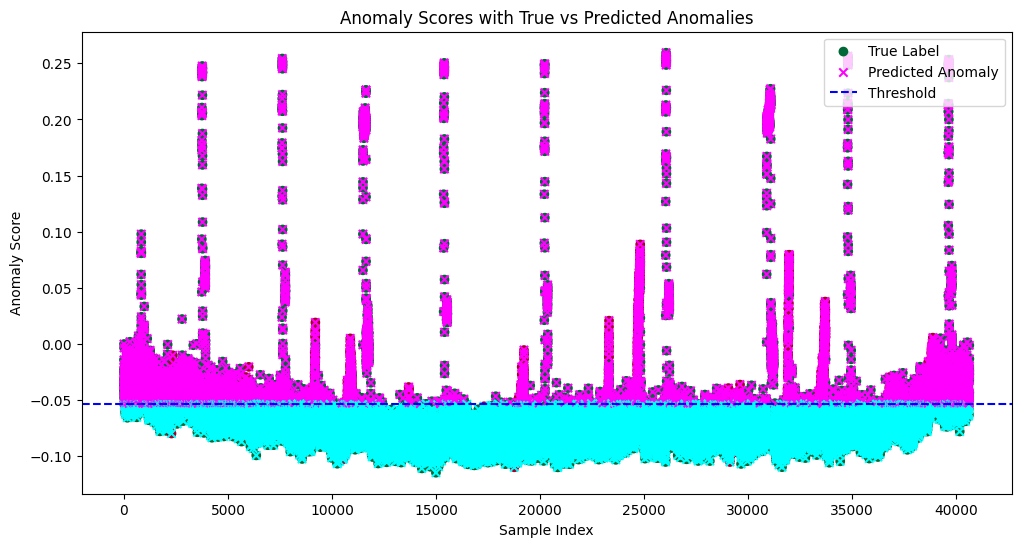

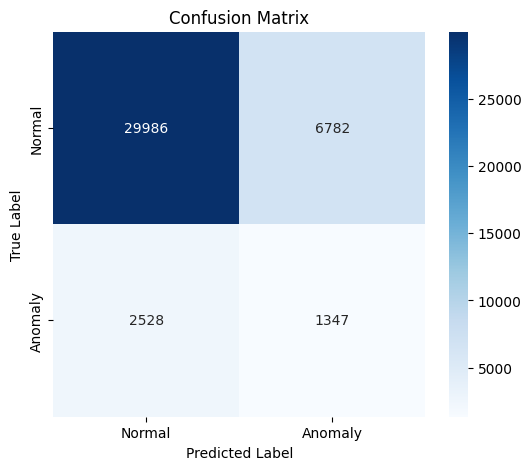

Number of anomalies detected: 8129


In [100]:
plt.figure(figsize=(12,6))
indices = range(len(anomaly_scores))
plt.scatter(indices, anomaly_scores, c=true_labels, cmap='RdYlGn_r', label='True Label', marker='o')
plt.scatter(indices, anomaly_scores, c=predicted_labels, cmap='cool', label='Predicted Anomaly', marker='x')
plt.axhline(threshold, color='blue', linestyle='--', label='Threshold')
plt.title('Anomaly Scores with True vs Predicted Anomalies')
plt.xlabel('Sample Index')
plt.ylabel('Anomaly Score')
plt.legend(loc='upper right')
plt.show()

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

num_anomalies = train_df_processed.filter(pl.col("predicted_anomaly") == 1).height
print(f"Number of anomalies detected: {num_anomalies}")

**Key Takeaways:**
- We sacrificed a bit of overall accuracy to significantly improve anomaly detection, which is exactly what we want in an early warning system.
- The model now detects 35% of real anomalies (vs just 9% before).
- This trade-off is necessary in high-risk domains where missing anomalies is more costly than false alarms.

## Potential Future Work: Enhancing Anomaly Detection and Proactive Health Monitoring

- Our goal was to go **beyond predictive modeling** and focus on building an **Early Warning System** by detecting operational anomalies that precede critical monitoring alerts. This helps enable **proactive intervention** and supports **optimized system health**

#### Ensemble of Detection Models
- Combine Isolation Forest with:
  - **Autoencoders** or other deep learning-based modelsnd broader anomaly capture.

#### Root Cause and Impact Analysis
- Extend anomaly detection with **feature explainability** to understand:
  - What features caused each anomaly?
  - How severe the anomaly is (risk scoring)?

### Conclusion

The current anomaly detection system using Isolation Forest shows promise but can be significantly improved by integrating **temporal dynamics**, **deep learning**, **ensemble methods**, and **real-time feedback**. These steps will move the system from being reactive to truly **predictive and adaptive**, making it intelligent operational health monitoring.
